In [ ]:
# ============================================
# CNN — CELL 1: Setup
# ============================================

import os
import glob
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from google.colab import drive

drive.mount("/content/drive")

DATA_ROOT = "/content/drive/MyDrive/music-genre-capstone/data"
FEATURE_ROOT = os.path.join(DATA_ROOT, "features")

MODEL_ROOT = "/content/drive/MyDrive/music-genre-capstone/models"
CNN_MODEL_ROOT = os.path.join(MODEL_ROOT, "cnn")

os.makedirs(CNN_MODEL_ROOT, exist_ok=True)

TRAIN_DIR = os.path.join(FEATURE_ROOT, "training_final")
VAL_DIR = os.path.join(FEATURE_ROOT, "validation_final")
TEST_DIR = os.path.join(FEATURE_ROOT, "test_final")

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("Training feature directory:", TRAIN_DIR)
print("Validation feature directory:", VAL_DIR)
print("Test feature directory:", TEST_DIR)
print("CNN model directory:", CNN_MODEL_ROOT)

Mounted at /content/drive
Device: cuda
GPU: Tesla T4
Training feature directory: /content/drive/MyDrive/music-genre-capstone/data/features/training_final
Validation feature directory: /content/drive/MyDrive/music-genre-capstone/data/features/validation_final
Test feature directory: /content/drive/MyDrive/music-genre-capstone/data/features/test_final
CNN model directory: /content/drive/MyDrive/music-genre-capstone/models/cnn


In [ ]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU: Not available")

CUDA available: True
GPU: Tesla T4


In [ ]:
# ============================================
# CNN — CELL 2: Verify Feature Shards
# ============================================

train_shards = sorted(
    glob.glob(os.path.join(TRAIN_DIR, "*.npz"))
)

val_shards = sorted(
    glob.glob(os.path.join(VAL_DIR, "*.npz"))
)

test_shards = sorted(
    glob.glob(os.path.join(TEST_DIR, "*.npz"))
)

print("Training shards:", len(train_shards))
print("Validation shards:", len(val_shards))
print("Test shards:", len(test_shards))

print("\nFirst training shard:")
print(train_shards[0])

data = np.load(train_shards[0])

print("\nKeys:", data.files)

for key in data.files:
    print(key, data[key].shape, data[key].dtype)

Training shards: 40
Validation shards: 6
Test shards: 6

First training shard:
/content/drive/MyDrive/music-genre-capstone/data/features/training_final/shard_000.npz

Keys: ['track_id', 'genre', 'ann_features', 'mel_features']
track_id (500,) int64
genre (500,) <U13
ann_features (500, 80) float32
mel_features (500, 128, 1292) float16


In [ ]:
# ============================================
# CNN — CELL 3: Class Distribution
# ============================================

train_genres = []
val_genres = []
test_genres = []

# Training shards
for shard_path in train_shards:
    data = np.load(shard_path)
    train_genres.extend(data["genre"].tolist())

# Validation shards
for shard_path in val_shards:
    data = np.load(shard_path)
    val_genres.extend(data["genres"].tolist())

# Test shards
for shard_path in test_shards:
    data = np.load(shard_path)
    test_genres.extend(data["genres"].tolist())

train_genres = np.array(train_genres)
val_genres = np.array(val_genres)
test_genres = np.array(test_genres)

print("Training samples:", len(train_genres))
print("Validation samples:", len(val_genres))
print("Test samples:", len(test_genres))

print("\nNumber of classes:", len(np.unique(train_genres)))

print("\nTraining class distribution:")
print(
    pd.Series(train_genres)
    .value_counts()
    .sort_index()
)

Training samples: 19909
Validation samples: 2504
Test samples: 2572

Number of classes: 16

Training class distribution:
Blues                    58
Classical               495
Country                 142
Easy Listening           13
Electronic             5048
Experimental           1800
Folk                   1214
Hip-Hop                1757
Instrumental           1044
International           814
Jazz                    306
Old-Time / Historic     408
Pop                     945
Rock                   5677
Soul-RnB                 94
Spoken                   94
Name: count, dtype: int64


In [ ]:
# ============================================
# CNN — CELL 4: Encode Genre Labels
# ============================================

label_encoder = LabelEncoder()

label_encoder.fit(train_genres)

train_labels = label_encoder.transform(train_genres)
val_labels = label_encoder.transform(val_genres)
test_labels = label_encoder.transform(test_genres)

num_classes = len(label_encoder.classes_)

print("Number of classes:", num_classes)

print("\nLabel mapping:")

for index, genre in enumerate(label_encoder.classes_):
    print(index, "->", genre)

print("\nEncoded shapes:")
print("Train:", train_labels.shape)
print("Validation:", val_labels.shape)
print("Test:", test_labels.shape)

Number of classes: 16

Label mapping:
0 -> Blues
1 -> Classical
2 -> Country
3 -> Easy Listening
4 -> Electronic
5 -> Experimental
6 -> Folk
7 -> Hip-Hop
8 -> Instrumental
9 -> International
10 -> Jazz
11 -> Old-Time / Historic
12 -> Pop
13 -> Rock
14 -> Soul-RnB
15 -> Spoken

Encoded shapes:
Train: (19909,)
Validation: (2504,)
Test: (2572,)


In [ ]:
# ============================================
# CNN — CELL 5: Calculate Class Weights
# ============================================

class_counts = np.bincount(
    train_labels,
    minlength=num_classes
)

total_samples = len(train_labels)

class_weights = total_samples / (
    num_classes * class_counts
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
)

print("Class weights:")

for index in range(num_classes):
    print(
        f"{index:2d} -> "
        f"{label_encoder.classes_[index]:20s} "
        f"count={class_counts[index]:5d} "
        f"weight={class_weights[index]:.4f}"
    )

Class weights:
 0 -> Blues                count=   58 weight=21.4537
 1 -> Classical            count=  495 weight=2.5138
 2 -> Country              count=  142 weight=8.7628
 3 -> Easy Listening       count=   13 weight=95.7163
 4 -> Electronic           count= 5048 weight=0.2465
 5 -> Experimental         count= 1800 weight=0.6913
 6 -> Folk                 count= 1214 weight=1.0250
 7 -> Hip-Hop              count= 1757 weight=0.7082
 8 -> Instrumental         count= 1044 weight=1.1919
 9 -> International        count=  814 weight=1.5286
10 -> Jazz                 count=  306 weight=4.0664
11 -> Old-Time / Historic  count=  408 weight=3.0498
12 -> Pop                  count=  945 weight=1.3167
13 -> Rock                 count= 5677 weight=0.2192
14 -> Soul-RnB             count=   94 weight=13.2374
15 -> Spoken               count=   94 weight=13.2374


In [ ]:
# ============================================
# CNN — CELL 6: Shard-Based Dataset
# ============================================

class MelSpectrogramDataset(Dataset):

    def __init__(self, shard_paths, label_encoder):
        self.shard_paths = shard_paths
        self.label_encoder = label_encoder

        self.shard_sizes = []
        self.total_samples = 0

        for shard_path in shard_paths:
            data = np.load(shard_path)

            size = len(data["track_id"])

            self.shard_sizes.append(size)
            self.total_samples += size

        self.current_shard_index = None
        self.current_mel = None
        self.current_genres = None

    def __len__(self):
        return self.total_samples

    def _load_shard(self, shard_index):

        if self.current_shard_index == shard_index:
            return

        data = np.load(self.shard_paths[shard_index])

        self.current_mel = data["mel_features"]

        if "genre" in data.files:
            self.current_genres = data["genre"]
        else:
            self.current_genres = data["genres"]

        self.current_shard_index = shard_index

    def __getitem__(self, index):

        running_total = 0

        for shard_index, shard_size in enumerate(self.shard_sizes):

            if index < running_total + shard_size:

                local_index = index - running_total

                self._load_shard(shard_index)

                mel = self.current_mel[local_index]
                genre = self.current_genres[local_index]

                label = self.label_encoder.transform(
                    [genre]
                )[0]

                mel = torch.tensor(
                    mel,
                    dtype=torch.float32
                )

                label = torch.tensor(
                    label,
                    dtype=torch.long
                )

                return mel, label

            running_total += shard_size

        raise IndexError("Index out of range")


train_dataset = MelSpectrogramDataset(
    train_shards,
    label_encoder
)

val_dataset = MelSpectrogramDataset(
    val_shards,
    label_encoder
)

test_dataset = MelSpectrogramDataset(
    test_shards,
    label_encoder
)

print("Train dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Test dataset:", len(test_dataset))

Train dataset: 19909
Validation dataset: 2504
Test dataset: 2572


In [ ]:
# ============================================
# CNN — CELL 7: Test Dataset Sample
# ============================================

mel_sample, label_sample = train_dataset[0]

print("Mel shape:", mel_sample.shape)
print("Mel dtype:", mel_sample.dtype)
print("Label:", label_sample.item())
print("Genre:", label_encoder.classes_[label_sample.item()])
print("Min value:", mel_sample.min().item())
print("Max value:", mel_sample.max().item())

Mel shape: torch.Size([128, 1292])
Mel dtype: torch.float32
Label: 7
Genre: Hip-Hop
Min value: -80.0
Max value: 0.0


In [ ]:
# ============================================
# CNN — CELL 8: Create DataLoaders
# ============================================

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("Batch size:", BATCH_SIZE)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Batch size: 32
Training batches: 623
Validation batches: 79
Test batches: 81


In [ ]:
# ============================================
# CNN — CELL 9: Test One Batch
# ============================================

mel_batch, label_batch = next(iter(train_loader))

print("Mel batch shape:", mel_batch.shape)
print("Mel batch dtype:", mel_batch.dtype)

print("Label batch shape:", label_batch.shape)
print("Label batch dtype:", label_batch.dtype)

print("First 10 labels:")
print(label_batch[:10])

Mel batch shape: torch.Size([32, 128, 1292])
Mel batch dtype: torch.float32
Label batch shape: torch.Size([32])
Label batch dtype: torch.int64
First 10 labels:
tensor([13,  5, 13,  4, 13,  4,  7,  4,  4, 13])


In [ ]:
# ============================================
# CNN — CELL 10: Define CNN Model
# ============================================

class MusicCNN(nn.Module):

    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(
                in_channels=1,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Block 2
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Block 3
            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):

        x = x.unsqueeze(1)

        x = self.features(x)

        x = self.pool(x)

        x = self.classifier(x)

        return x


model = MusicCNN(num_classes)

model = model.to(device)

print(model)

MusicCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=128, out_features=6

In [ ]:
# ============================================
# CNN — CELL 11: Test Model
# ============================================

total_params = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_params = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

# Test one batch through the model
mel_batch, label_batch = next(iter(train_loader))

mel_batch = mel_batch.to(device)
label_batch = label_batch.to(device)

with torch.no_grad():
    output = model(mel_batch)

print("\nInput shape:", mel_batch.shape)
print("Output shape:", output.shape)
print("Labels shape:", label_batch.shape)

Total parameters: 102416
Trainable parameters: 102416

Input shape: torch.Size([32, 128, 1292])
Output shape: torch.Size([32, 16])
Labels shape: torch.Size([32])


In [ ]:
# ============================================
# CNN — CELL 12: Loss Function + Optimizer
# ============================================

class_weights = class_weights.to(device)

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss function:", criterion)
print("Optimizer:", optimizer)
print("Learning rate:", 0.001)

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
Learning rate: 0.001


In [ ]:
def spec_augment(
    mel,
    frequency_mask=12,
    time_mask=80
):

    mel = mel.clone()

    batch_size = mel.shape[0]
    num_mels = mel.shape[1]
    num_frames = mel.shape[2]

    mask_value = mel.min().item()

    for i in range(batch_size):

        # Frequency masking
        freq_width = np.random.randint(
            0,
            frequency_mask + 1
        )

        if freq_width > 0:
            freq_start = np.random.randint(
                0,
                num_mels - freq_width + 1
            )

            mel[
                i,
                freq_start:freq_start + freq_width,
                :
            ] = mask_value

        # Time masking
        time_width = np.random.randint(
            0,
            time_mask + 1
        )

        if time_width > 0:
            time_start = np.random.randint(
                0,
                num_frames - time_width + 1
            )

            mel[
                i,
                :,
                time_start:time_start + time_width
            ] = mask_value

    return mel


augmented_batch = spec_augment(mel_batch)

print("Original shape:", mel_batch.shape)
print("Augmented shape:", augmented_batch.shape)
print("Original min/max:", mel_batch.min().item(), mel_batch.max().item())
print("Augmented min/max:", augmented_batch.min().item(), augmented_batch.max().item())

Original shape: torch.Size([32, 128, 1292])
Augmented shape: torch.Size([32, 128, 1292])
Original min/max: -80.0 0.0
Augmented min/max: -80.0 0.0


In [ ]:
# ============================================
# CNN — CELL 14: Train CNN
# ============================================

NUM_EPOCHS = 15

best_val_accuracy = 0.0

train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

best_model_path = os.path.join(
    CNN_MODEL_ROOT,
    "best_cnn_model.pth"
)

for epoch in range(NUM_EPOCHS):

    # -------------------------
    # Training
    # -------------------------

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    start_time = time.time()

    for mel_batch, label_batch in train_loader:

        mel_batch = mel_batch.to(
            device,
            non_blocking=True
        )

        label_batch = label_batch.to(
            device,
            non_blocking=True
        )

        # Apply augmentation
        mel_batch = spec_augment(mel_batch)

        optimizer.zero_grad()

        outputs = model(mel_batch)

        loss = criterion(
            outputs,
            label_batch
        )

        loss.backward()

        optimizer.step()

        running_loss += (
            loss.item() * label_batch.size(0)
        )

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        correct += (
            predictions == label_batch
        ).sum().item()

        total += label_batch.size(0)

    train_loss = running_loss / total
    train_accuracy = correct / total

    # -------------------------
    # Validation
    # -------------------------

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for mel_batch, label_batch in val_loader:

            mel_batch = mel_batch.to(
                device,
                non_blocking=True
            )

            label_batch = label_batch.to(
                device,
                non_blocking=True
            )

            outputs = model(mel_batch)

            loss = criterion(
                outputs,
                label_batch
            )

            running_loss += (
                loss.item() * label_batch.size(0)
            )

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            correct += (
                predictions == label_batch
            ).sum().item()

            total += label_batch.size(0)

    val_loss = running_loss / total
    val_accuracy = correct / total

    # -------------------------
    # Save metrics
    # -------------------------

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    epoch_time = time.time() - start_time

    print(
        f"Epoch [{epoch + 1}/{NUM_EPOCHS}] "
        f"Time: {epoch_time:.1f}s "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_accuracy:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_accuracy:.4f}"
    )

    # -------------------------
    # Save best model
    # -------------------------

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        torch.save(
            model.state_dict(),
            best_model_path
        )

        print(
            f"  Saved best model "
            f"(Val Acc: {val_accuracy:.4f})"
        )

print("\nTraining complete.")
print("Best validation accuracy:", best_val_accuracy)
print("Best model:", best_model_path)

KeyboardInterrupt: 

In [ ]:
import os
import shutil
import glob
import time

LOCAL_FEATURE_ROOT = "/content/cnn_features"

LOCAL_TRAIN_DIR = os.path.join(
    LOCAL_FEATURE_ROOT,
    "training_final"
)

LOCAL_VAL_DIR = os.path.join(
    LOCAL_FEATURE_ROOT,
    "validation_final"
)

os.makedirs(LOCAL_TRAIN_DIR, exist_ok=True)
os.makedirs(LOCAL_VAL_DIR, exist_ok=True)

print("Copying training shards to Colab local disk...")

start_time = time.time()

for shard_path in train_shards:

    destination = os.path.join(
        LOCAL_TRAIN_DIR,
        os.path.basename(shard_path)
    )

    if not os.path.exists(destination):
        shutil.copy2(shard_path, destination)

    print(
        "Copied:",
        os.path.basename(shard_path)
    )

print(
    "\nTraining copy complete."
)

print(
    "Time:",
    round(time.time() - start_time, 1),
    "seconds"
)

print(
    "Local training shards:",
    len(
        glob.glob(
            os.path.join(
                LOCAL_TRAIN_DIR,
                "*.npz"
            )
        )
    )
)

Copying training shards to Colab local disk...
Copied: shard_000.npz
Copied: shard_001.npz
Copied: shard_002.npz
Copied: shard_003.npz
Copied: shard_004.npz
Copied: shard_005.npz
Copied: shard_006.npz
Copied: shard_007.npz
Copied: shard_008.npz
Copied: shard_009.npz
Copied: shard_010.npz
Copied: shard_011.npz
Copied: shard_012.npz
Copied: shard_013.npz
Copied: shard_014.npz
Copied: shard_015.npz
Copied: shard_016.npz
Copied: shard_017.npz
Copied: shard_018.npz
Copied: shard_019.npz
Copied: shard_020.npz
Copied: shard_021.npz
Copied: shard_022.npz
Copied: shard_023.npz
Copied: shard_024.npz
Copied: shard_025.npz
Copied: shard_026.npz
Copied: shard_027.npz
Copied: shard_028.npz
Copied: shard_029.npz
Copied: shard_030.npz
Copied: shard_031.npz
Copied: shard_032.npz
Copied: shard_033.npz
Copied: shard_034.npz
Copied: shard_035.npz
Copied: shard_036.npz
Copied: shard_037.npz
Copied: shard_038.npz
Copied: shard_039.npz

Training copy complete.
Time: 63.1 seconds
Local training shards: 40


In [ ]:
id="z7k3m2"
LOCAL_TRAIN_DIR = "/content/cnn_features/training_final"
LOCAL_VAL_DIR = "/content/cnn_features/validation_final"

local_train_shards = sorted(
    glob.glob(
        os.path.join(
            LOCAL_TRAIN_DIR,
            "*.npz"
        )
    )
)

print("Local training shards:", len(local_train_shards))

print("First shard:")
print(local_train_shards[0])

data = np.load(local_train_shards[0])

print("\nKeys:", data.files)

for key in data.files:
    print(
        key,
        data[key].shape,
        data[key].dtype
    )

Local training shards: 40
First shard:
/content/cnn_features/training_final/shard_000.npz

Keys: ['track_id', 'genre', 'ann_features', 'mel_features']
track_id (500,) int64
genre (500,) <U13
ann_features (500, 80) float32
mel_features (500, 128, 1292) float16


In [ ]:
train_dataset_local = MelSpectrogramDataset(
    local_train_shards,
    label_encoder
)

print("Local training dataset:", len(train_dataset_local))

mel_sample, label_sample = train_dataset_local[0]

print("Sample shape:", mel_sample.shape)
print("Sample dtype:", mel_sample.dtype)
print("Label:", label_sample.item())
print("Genre:", label_encoder.classes_[label_sample.item()])

Local training dataset: 19909
Sample shape: torch.Size([128, 1292])
Sample dtype: torch.float32
Label: 7
Genre: Hip-Hop


In [ ]:
local_train_loader = DataLoader(
    train_dataset_local,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

print("Local training batches:", len(local_train_loader))

start_time = time.time()

mel_batch, label_batch = next(iter(local_train_loader))

elapsed = time.time() - start_time

print("Batch shape:", mel_batch.shape)
print("Labels shape:", label_batch.shape)
print("Time to load first batch:", round(elapsed, 2), "seconds")

Local training batches: 623
Batch shape: torch.Size([32, 128, 1292])
Labels shape: torch.Size([32])
Time to load first batch: 17.56 seconds


In [ ]:
import psutil

ram = psutil.virtual_memory()

print("Total RAM:", round(ram.total / (1024**3), 2), "GB")
print("Available RAM:", round(ram.available / (1024**3), 2), "GB")
print("Used RAM:", round(ram.used / (1024**3), 2), "GB")

Total RAM: 12.67 GB
Available RAM: 9.64 GB
Used RAM: 2.64 GB


In [ ]:
print("Loading training features into RAM...")

start_time = time.time()

train_mels = []
train_labels_ram = []

for shard_number, shard_path in enumerate(local_train_shards):

    data = np.load(shard_path)

    train_mels.append(
        data["mel_features"]
    )

    shard_genres = data["genre"]

    shard_labels = label_encoder.transform(
        shard_genres
    )

    train_labels_ram.append(
        shard_labels
    )

    print(
        f"Loaded shard {shard_number + 1}/{len(local_train_shards)}"
    )

train_mels = np.concatenate(
    train_mels,
    axis=0
)

train_labels_ram = np.concatenate(
    train_labels_ram,
    axis=0
)

print("\nLoading complete.")

print("Mel shape:", train_mels.shape)
print("Mel dtype:", train_mels.dtype)
print("Labels shape:", train_labels_ram.shape)
print("Time:", round(time.time() - start_time, 1), "seconds")

print(
    "Mel RAM usage:",
    round(train_mels.nbytes / (1024**3), 2),
    "GB"
)

Loading training features into RAM...
Loaded shard 1/40
Loaded shard 2/40
Loaded shard 3/40
Loaded shard 4/40
Loaded shard 5/40
Loaded shard 6/40
Loaded shard 7/40
Loaded shard 8/40
Loaded shard 9/40
Loaded shard 10/40
Loaded shard 11/40
Loaded shard 12/40
Loaded shard 13/40
Loaded shard 14/40
Loaded shard 15/40
Loaded shard 16/40
Loaded shard 17/40
Loaded shard 18/40
Loaded shard 19/40
Loaded shard 20/40
Loaded shard 21/40
Loaded shard 22/40
Loaded shard 23/40
Loaded shard 24/40
Loaded shard 25/40
Loaded shard 26/40
Loaded shard 27/40
Loaded shard 28/40
Loaded shard 29/40
Loaded shard 30/40
Loaded shard 31/40
Loaded shard 32/40
Loaded shard 33/40
Loaded shard 34/40
Loaded shard 35/40
Loaded shard 36/40
Loaded shard 37/40
Loaded shard 38/40
Loaded shard 39/40
Loaded shard 40/40


In [ ]:
print("Runtime is alive")

Runtime is alive


In [ ]:
import os
import glob
import shutil
import time
import numpy as np

DATA_ROOT = "/content/drive/MyDrive/music-genre-capstone/data"
FEATURE_ROOT = os.path.join(DATA_ROOT, "features")

TRAIN_DIR = os.path.join(
    FEATURE_ROOT,
    "training_final"
)

LOCAL_FEATURE_ROOT = "/content/cnn_features"
LOCAL_TRAIN_DIR = os.path.join(
    LOCAL_FEATURE_ROOT,
    "training_final"
)

os.makedirs(LOCAL_TRAIN_DIR, exist_ok=True)

train_shards = sorted(
    glob.glob(
        os.path.join(
            TRAIN_DIR,
            "*.npz"
        )
    )
)

print("Training shards in Drive:", len(train_shards))

start_time = time.time()

for shard_path in train_shards:

    destination = os.path.join(
        LOCAL_TRAIN_DIR,
        os.path.basename(shard_path)
    )

    shutil.copy2(
        shard_path,
        destination
    )

print(
    "Copied all training shards."
)

print(
    "Time:",
    round(time.time() - start_time, 1),
    "seconds"
)

local_train_shards = sorted(
    glob.glob(
        os.path.join(
            LOCAL_TRAIN_DIR,
            "*.npz"
        )
    )
)

print(
    "Local training shards:",
    len(local_train_shards)
)

Training shards in Drive: 40
Copied all training shards.
Time: 59.8 seconds
Local training shards: 40


In [ ]:
from bisect import bisect_right
from torch.utils.data import Dataset

class FastMelSpectrogramDataset(Dataset):

    def __init__(self, shard_paths, label_encoder):

        self.shard_paths = shard_paths
        self.label_encoder = label_encoder

        self.shard_sizes = []
        self.cumulative_sizes = []

        total = 0

        for shard_path in shard_paths:

            data = np.load(shard_path)

            size = len(data["track_id"])

            self.shard_sizes.append(size)

            total += size

            self.cumulative_sizes.append(total)

        self.total_samples = total

        self.current_shard_index = None
        self.current_mel = None
        self.current_genres = None

    def __len__(self):
        return self.total_samples

    def _load_shard(self, shard_index):

        if self.current_shard_index == shard_index:
            return

        data = np.load(
            self.shard_paths[shard_index]
        )

        self.current_mel = data["mel_features"]

        if "genre" in data.files:
            self.current_genres = data["genre"]
        else:
            self.current_genres = data["genres"]

        self.current_shard_index = shard_index

    def __getitem__(self, index):

        shard_index = bisect_right(
            self.cumulative_sizes,
            index
        )

        if shard_index == 0:
            local_index = index
        else:
            local_index = (
                index -
                self.cumulative_sizes[shard_index - 1]
            )

        self._load_shard(shard_index)

        mel = self.current_mel[local_index]

        genre = self.current_genres[local_index]

        label = self.label_encoder.transform(
            [genre]
        )[0]

        mel = torch.tensor(
            mel,
            dtype=torch.float32
        )

        label = torch.tensor(
            label,
            dtype=torch.long
        )

        return mel, label


train_dataset_fast = FastMelSpectrogramDataset(
    local_train_shards,
    label_encoder
)

print(
    "Training samples:",
    len(train_dataset_fast)
)

NameError: name 'label_encoder' is not defined

In [ ]:
from sklearn.preprocessing import LabelEncoder

train_genres = []

for shard_path in local_train_shards:

    data = np.load(shard_path)

    train_genres.extend(
        data["genre"].tolist()
    )

train_genres = np.array(train_genres)

label_encoder = LabelEncoder()

label_encoder.fit(train_genres)

num_classes = len(
    label_encoder.classes_
)

print("Training samples:", len(train_genres))
print("Number of classes:", num_classes)

print("\nLabel mapping:")

for index, genre in enumerate(label_encoder.classes_):
    print(index, "->", genre)

Training samples: 19909
Number of classes: 16

Label mapping:
0 -> Blues
1 -> Classical
2 -> Country
3 -> Easy Listening
4 -> Electronic
5 -> Experimental
6 -> Folk
7 -> Hip-Hop
8 -> Instrumental
9 -> International
10 -> Jazz
11 -> Old-Time / Historic
12 -> Pop
13 -> Rock
14 -> Soul-RnB
15 -> Spoken


In [ ]:
train_dataset_fast = FastMelSpectrogramDataset(
    local_train_shards,
    label_encoder
)

print("Training samples:", len(train_dataset_fast))

mel_sample, label_sample = train_dataset_fast[0]

print("Sample shape:", mel_sample.shape)
print("Sample dtype:", mel_sample.dtype)
print("Label:", label_sample.item())
print("Genre:", label_encoder.classes_[label_sample.item()])

Training samples: 19909


NameError: name 'torch' is not defined

In [ ]:
import os
import glob
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from google.colab import drive

# =========================
# Mount Drive
# =========================

drive.mount("/content/drive")

# =========================
# Paths
# =========================

DATA_ROOT = "/content/drive/MyDrive/music-genre-capstone/data"
FEATURE_ROOT = os.path.join(
    DATA_ROOT,
    "features"
)

MODEL_ROOT = "/content/drive/MyDrive/music-genre-capstone/models"
CNN_MODEL_ROOT = os.path.join(
    MODEL_ROOT,
    "cnn"
)

os.makedirs(
    CNN_MODEL_ROOT,
    exist_ok=True
)

TRAIN_DIR = os.path.join(
    FEATURE_ROOT,
    "training_final"
)

VAL_DIR = os.path.join(
    FEATURE_ROOT,
    "validation_final"
)

TEST_DIR = os.path.join(
    FEATURE_ROOT,
    "test_final"
)

# =========================
# Device
# =========================

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

# =========================
# Shards
# =========================

train_shards = sorted(
    glob.glob(
        os.path.join(
            TRAIN_DIR,
            "*.npz"
        )
    )
)

val_shards = sorted(
    glob.glob(
        os.path.join(
            VAL_DIR,
            "*.npz"
        )
    )
)

test_shards = sorted(
    glob.glob(
        os.path.join(
            TEST_DIR,
            "*.npz"
        )
    )
)

print("\nDrive shards:")
print("Training:", len(train_shards))
print("Validation:", len(val_shards))
print("Test:", len(test_shards))

# =========================
# Local training paths
# =========================

LOCAL_FEATURE_ROOT = "/content/cnn_features"

LOCAL_TRAIN_DIR = os.path.join(
    LOCAL_FEATURE_ROOT,
    "training_final"
)

os.makedirs(
    LOCAL_TRAIN_DIR,
    exist_ok=True
)

# =========================
# Copy training shards locally
# =========================

print("\nCopying training shards to local Colab disk...")

start_time = time.time()

for shard_path in train_shards:

    destination = os.path.join(
        LOCAL_TRAIN_DIR,
        os.path.basename(shard_path)
    )

    if not os.path.exists(destination):

        import shutil

        shutil.copy2(
            shard_path,
            destination
        )

local_train_shards = sorted(
    glob.glob(
        os.path.join(
            LOCAL_TRAIN_DIR,
            "*.npz"
        )
    )
)

print(
    "Local training shards:",
    len(local_train_shards)
)

print(
    "Copy time:",
    round(
        time.time() - start_time,
        1
    ),
    "seconds"
)

# =========================
# Label encoder
# =========================

train_genres = []

for shard_path in local_train_shards:

    data = np.load(shard_path)

    train_genres.extend(
        data["genre"].tolist()
    )

train_genres = np.array(
    train_genres
)

label_encoder = LabelEncoder()

label_encoder.fit(
    train_genres
)

num_classes = len(
    label_encoder.classes_
)

train_labels = label_encoder.transform(
    train_genres
)

print(
    "\nTraining samples:",
    len(train_genres)
)

print(
    "Number of classes:",
    num_classes
)

print("\nLabel mapping:")

for index, genre in enumerate(
    label_encoder.classes_
):

    print(
        index,
        "->",
        genre
    )

# =========================
# Class weights
# =========================

class_counts = np.bincount(
    train_labels,
    minlength=num_classes
)

total_samples = len(
    train_labels
)

class_weights = total_samples / (
    num_classes * class_counts
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
)

print("\nClass weights ready.")

# =========================
# Dataset
# =========================

from bisect import bisect_right


class FastMelSpectrogramDataset(Dataset):

    def __init__(
        self,
        shard_paths,
        label_encoder
    ):

        self.shard_paths = shard_paths
        self.label_encoder = label_encoder

        self.shard_sizes = []
        self.cumulative_sizes = []

        total = 0

        for shard_path in shard_paths:

            data = np.load(
                shard_path
            )

            size = len(
                data["track_id"]
            )

            self.shard_sizes.append(
                size
            )

            total += size

            self.cumulative_sizes.append(
                total
            )

        self.total_samples = total

        self.current_shard_index = None
        self.current_mel = None
        self.current_genres = None

    def __len__(self):

        return self.total_samples

    def _load_shard(
        self,
        shard_index
    ):

        if (
            self.current_shard_index
            == shard_index
        ):

            return

        data = np.load(
            self.shard_paths[
                shard_index
            ]
        )

        self.current_mel = data[
            "mel_features"
        ]

        if "genre" in data.files:

            self.current_genres = data[
                "genre"
            ]

        else:

            self.current_genres = data[
                "genres"
            ]

        self.current_shard_index = (
            shard_index
        )

    def __getitem__(
        self,
        index
    ):

        shard_index = bisect_right(
            self.cumulative_sizes,
            index
        )

        if shard_index == 0:

            local_index = index

        else:

            local_index = (
                index
                - self.cumulative_sizes[
                    shard_index - 1
                ]
            )

        self._load_shard(
            shard_index
        )

        mel = self.current_mel[
            local_index
        ]

        genre = self.current_genres[
            local_index
        ]

        label = self.label_encoder.transform(
            [genre]
        )[0]

        mel = torch.tensor(
            mel,
            dtype=torch.float32
        )

        label = torch.tensor(
            label,
            dtype=torch.long
        )

        return mel, label


train_dataset_fast = FastMelSpectrogramDataset(
    local_train_shards,
    label_encoder
)

print(
    "\nFast dataset:",
    len(train_dataset_fast)
)

# =========================
# DataLoader
# =========================

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset_fast,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

print(
    "Training batches:",
    len(train_loader)
)

# =========================
# Test sample
# =========================

mel_sample, label_sample = (
    train_dataset_fast[0]
)

print(
    "\nSample shape:",
    mel_sample.shape
)

print(
    "Sample dtype:",
    mel_sample.dtype
)

print(
    "Sample label:",
    label_sample.item()
)

print(
    "Sample genre:",
    label_encoder.classes_[
        label_sample.item()
    ]
)

print("\nCNN environment ready.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda
GPU: Tesla T4

Drive shards:
Training: 40
Validation: 6
Test: 6

Copying training shards to local Colab disk...
Local training shards: 40
Copy time: 0.0 seconds

Training samples: 19909
Number of classes: 16

Label mapping:
0 -> Blues
1 -> Classical
2 -> Country
3 -> Easy Listening
4 -> Electronic
5 -> Experimental
6 -> Folk
7 -> Hip-Hop
8 -> Instrumental
9 -> International
10 -> Jazz
11 -> Old-Time / Historic
12 -> Pop
13 -> Rock
14 -> Soul-RnB
15 -> Spoken

Class weights ready.

Fast dataset: 19909
Training batches: 623

Sample shape: torch.Size([128, 1292])
Sample dtype: torch.float32
Sample label: 7
Sample genre: Hip-Hop

CNN environment ready.


In [ ]:
print("Testing first batch...")

start_time = time.time()

mel_batch, label_batch = next(iter(train_loader))

elapsed = time.time() - start_time

print("Batch shape:", mel_batch.shape)
print("Labels shape:", label_batch.shape)
print("Batch dtype:", mel_batch.dtype)
print("Time to load first batch:", round(elapsed, 2), "seconds")

Testing first batch...
Batch shape: torch.Size([32, 128, 1292])
Labels shape: torch.Size([32])
Batch dtype: torch.float32
Time to load first batch: 15.96 seconds


In [ ]:
from torch.utils.data import IterableDataset, DataLoader


class ShuffledShardDataset(IterableDataset):

    def __init__(
        self,
        shard_paths,
        label_encoder,
        shuffle=True
    ):
        self.shard_paths = shard_paths
        self.label_encoder = label_encoder
        self.shuffle = shuffle

    def __iter__(self):

        shard_order = np.arange(
            len(self.shard_paths)
        )

        if self.shuffle:
            np.random.shuffle(
                shard_order
            )

        for shard_index in shard_order:

            shard_path = self.shard_paths[
                shard_index
            ]

            data = np.load(
                shard_path
            )

            mel_features = data[
                "mel_features"
            ]

            if "genre" in data.files:
                genres = data["genre"]
            else:
                genres = data["genres"]

            sample_order = np.arange(
                len(genres)
            )

            if self.shuffle:
                np.random.shuffle(
                    sample_order
                )

            for index in sample_order:

                mel = mel_features[index]

                genre = genres[index]

                label = self.label_encoder.transform(
                    [genre]
                )[0]

                mel = torch.tensor(
                    mel,
                    dtype=torch.float32
                )

                label = torch.tensor(
                    label,
                    dtype=torch.long
                )

                yield mel, label


# Create new training dataset

train_dataset_shard = ShuffledShardDataset(
    local_train_shards,
    label_encoder,
    shuffle=True
)


# Create new DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset_shard,
    batch_size=BATCH_SIZE,
    num_workers=0,
    pin_memory=True
)


print(
    "Training batches:",
    19909 // BATCH_SIZE + (
        1 if 19909 % BATCH_SIZE != 0 else 0
    )
)


# Test first batch

print("\nTesting shard-aware loader...")

start_time = time.time()

mel_batch, label_batch = next(
    iter(train_loader)
)

elapsed = time.time() - start_time

print(
    "Batch shape:",
    mel_batch.shape
)

print(
    "Labels shape:",
    label_batch.shape
)

print(
    "Batch dtype:",
    mel_batch.dtype
)

print(
    "Time to load first batch:",
    round(elapsed, 2),
    "seconds"
)

Training batches: 623

Testing shard-aware loader...
Batch shape: torch.Size([32, 128, 1292])
Labels shape: torch.Size([32])
Batch dtype: torch.float32
Time to load first batch: 1.5 seconds


In [ ]:
# =========================
# CNN MODEL
# =========================

class MusicCNN(nn.Module):

    def __init__(self, num_classes):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                1,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(64),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                64,
                128,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(128),

            nn.ReLU(),

            nn.MaxPool2d(2)
        )

        self.pool = nn.AdaptiveAvgPool2d(
            (1, 1)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                128,
                64
            ),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(
                64,
                num_classes
            )
        )

    def forward(self, x):

        x = x.unsqueeze(1)

        x = self.features(x)

        x = self.pool(x)

        x = self.classifier(x)

        return x


# =========================
# Create model
# =========================

model = MusicCNN(
    num_classes
).to(device)


# =========================
# Loss
# =========================

class_weights = class_weights.to(
    device
)

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)


# =========================
# Optimizer
# =========================

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)


# =========================
# SpecAugment
# =========================

def spec_augment(
    mel,
    frequency_mask=12,
    time_mask=80
):

    mel = mel.clone()

    batch_size = mel.shape[0]

    num_mels = mel.shape[1]

    num_frames = mel.shape[2]

    mask_value = mel.min().item()

    for i in range(batch_size):

        freq_width = np.random.randint(
            0,
            frequency_mask + 1
        )

        if freq_width > 0:

            freq_start = np.random.randint(
                0,
                num_mels - freq_width + 1
            )

            mel[
                i,
                freq_start:freq_start + freq_width,
                :
            ] = mask_value

        time_width = np.random.randint(
            0,
            time_mask + 1
        )

        if time_width > 0:

            time_start = np.random.randint(
                0,
                num_frames - time_width + 1
            )

            mel[
                i,
                :,
                time_start:time_start + time_width
            ] = mask_value

    return mel


# =========================
# Model information
# =========================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Model:", model.__class__.__name__)
print("Number of classes:", num_classes)
print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)
print("Device:", device)
print("Loss: Weighted CrossEntropyLoss")
print("Optimizer: Adam")
print("Learning rate: 0.001")
print("SpecAugment: Enabled")

Model: MusicCNN
Number of classes: 16
Total parameters: 102416
Trainable parameters: 102416
Device: cuda
Loss: Weighted CrossEntropyLoss
Optimizer: Adam
Learning rate: 0.001
SpecAugment: Enabled


In [ ]:
print("Starting 1-epoch training test...")

model.train()

epoch_start = time.time()

running_loss = 0.0
correct = 0
total = 0

for batch_index, (mel_batch, label_batch) in enumerate(
    train_loader
):

    mel_batch = mel_batch.to(
        device,
        non_blocking=True
    )

    label_batch = label_batch.to(
        device,
        non_blocking=True
    )

    mel_batch = spec_augment(
        mel_batch
    )

    optimizer.zero_grad()

    outputs = model(
        mel_batch
    )

    loss = criterion(
        outputs,
        label_batch
    )

    loss.backward()

    optimizer.step()

    running_loss += (
        loss.item()
        * label_batch.size(0)
    )

    predictions = torch.argmax(
        outputs,
        dim=1
    )

    correct += (
        predictions == label_batch
    ).sum().item()

    total += label_batch.size(0)

    if (
        batch_index + 1
    ) % 100 == 0:

        print(
            "Batch:",
            batch_index + 1,
            "/",
            623
        )

epoch_time = (
    time.time()
    - epoch_start
)

epoch_loss = (
    running_loss / total
)

epoch_accuracy = (
    correct / total
)

print("\n1-epoch test complete.")

print(
    "Loss:",
    round(epoch_loss, 4)
)

print(
    "Accuracy:",
    round(epoch_accuracy * 100, 2),
    "%"
)

print(
    "Epoch time:",
    round(epoch_time, 2),
    "seconds"
)

print(
    "Estimated 15-epoch time:",
    round(epoch_time * 15 / 60, 2),
    "minutes"
)

Starting 1-epoch training test...
Batch: 100 / 623
Batch: 200 / 623
Batch: 300 / 623
Batch: 400 / 623
Batch: 500 / 623
Batch: 600 / 623

1-epoch test complete.
Loss: 2.51
Accuracy: 27.7 %
Epoch time: 167.59 seconds
Estimated 15-epoch time: 41.9 minutes


In [ ]:
from torch.utils.data import IterableDataset, DataLoader


class ShardBatchDataset(IterableDataset):

    def __init__(
        self,
        shard_paths,
        label_encoder,
        batch_size=32,
        shuffle=True
    ):
        self.shard_paths = shard_paths
        self.label_encoder = label_encoder
        self.batch_size = batch_size
        self.shuffle = shuffle

    def __iter__(self):

        shard_order = np.arange(
            len(self.shard_paths)
        )

        if self.shuffle:
            np.random.shuffle(
                shard_order
            )

        for shard_index in shard_order:

            shard_path = self.shard_paths[
                shard_index
            ]

            data = np.load(
                shard_path
            )

            # Load entire shard at once
            mel_features = data[
                "mel_features"
            ]

            if "genre" in data.files:
                genres = data["genre"]
            else:
                genres = data["genres"]

            # Convert entire shard once
            mel_features = torch.from_numpy(
                mel_features
            ).float()

            labels = self.label_encoder.transform(
                genres
            )

            labels = torch.from_numpy(
                labels
            ).long()

            # Shuffle within the shard
            sample_order = torch.randperm(
                len(labels)
            )

            mel_features = mel_features[
                sample_order
            ]

            labels = labels[
                sample_order
            ]

            # Yield complete batches
            for start in range(
                0,
                len(labels),
                self.batch_size
            ):

                end = start + self.batch_size

                yield (
                    mel_features[start:end],
                    labels[start:end]
                )


# =========================
# Create batch dataset
# =========================

train_dataset_batch = ShardBatchDataset(
    local_train_shards,
    label_encoder,
    batch_size=32,
    shuffle=True
)


# =========================
# DataLoader
# =========================

train_loader = DataLoader(
    train_dataset_batch,
    batch_size=None,
    num_workers=0,
    pin_memory=True
)


print(
    "Shard-batch loader ready."
)

print(
    "Expected batches:",
    623
)


# =========================
# Benchmark
# =========================

print("\nTesting new loader...")

start_time = time.time()

mel_batch, label_batch = next(
    iter(train_loader)
)

elapsed = time.time() - start_time

print(
    "Batch shape:",
    mel_batch.shape
)

print(
    "Labels shape:",
    label_batch.shape
)

print(
    "Batch dtype:",
    mel_batch.dtype
)

print(
    "Time to load first batch:",
    round(elapsed, 2),
    "seconds"
)

Shard-batch loader ready.
Expected batches: 623

Testing new loader...
Batch shape: torch.Size([32, 128, 1292])
Labels shape: torch.Size([32])
Batch dtype: torch.float32
Time to load first batch: 1.79 seconds


In [ ]:
# =========================
# Copy validation shards locally
# =========================

LOCAL_VAL_DIR = os.path.join(
    LOCAL_FEATURE_ROOT,
    "validation_final"
)

os.makedirs(
    LOCAL_VAL_DIR,
    exist_ok=True
)

print("Copying validation shards...")

start_time = time.time()

for shard_path in val_shards:

    destination = os.path.join(
        LOCAL_VAL_DIR,
        os.path.basename(shard_path)
    )

    if not os.path.exists(destination):

        import shutil

        shutil.copy2(
            shard_path,
            destination
        )

local_val_shards = sorted(
    glob.glob(
        os.path.join(
            LOCAL_VAL_DIR,
            "*.npz"
        )
    )
)

print(
    "Local validation shards:",
    len(local_val_shards)
)

print(
    "Copy time:",
    round(
        time.time() - start_time,
        2
    ),
    "seconds"
)


# =========================
# Validation dataset
# =========================

val_dataset_batch = ShardBatchDataset(
    local_val_shards,
    label_encoder,
    batch_size=32,
    shuffle=False
)


# =========================
# Validation DataLoader
# =========================

val_loader = DataLoader(
    val_dataset_batch,
    batch_size=None,
    num_workers=0,
    pin_memory=True
)


print(
    "Validation batches:",
    2504 // 32 + (
        1 if 2504 % 32 != 0 else 0
    )
)


# =========================
# Test validation batch
# =========================

start_time = time.time()

val_mel_batch, val_label_batch = next(
    iter(val_loader)
)

elapsed = time.time() - start_time

print(
    "Validation batch:",
    val_mel_batch.shape
)

print(
    "Validation load time:",
    round(elapsed, 2),
    "seconds"
)

Copying validation shards...
Local validation shards: 6
Copy time: 26.21 seconds
Validation batches: 79
Validation batch: torch.Size([32, 128, 1292])
Validation load time: 0.69 seconds


In [ ]:
# =========================
# CNN TRAINING
# =========================

NUM_EPOCHS_TOTAL = 15

best_val_accuracy = 0.0

training_history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
    "epoch_time": []
}

best_model_path = os.path.join(
    CNN_MODEL_ROOT,
    "best_cnn_model.pth"
)

print(
    "Starting CNN training..."
)

print(
    "Total epochs:",
    NUM_EPOCHS_TOTAL
)

print(
    "Already completed:",
    1
)

print(
    "Remaining:",
    NUM_EPOCHS_TOTAL - 1
)

print(
    "Best model path:",
    best_model_path
)

print()


# =========================
# Continue from epoch 2
# =========================

for epoch in range(
    2,
    NUM_EPOCHS_TOTAL + 1
):

    epoch_start = time.time()

    # -------------------------
    # Training
    # -------------------------

    model.train()

    running_train_loss = 0.0

    train_correct = 0
    train_total = 0

    for batch_index, (
        mel_batch,
        label_batch
    ) in enumerate(train_loader):

        mel_batch = mel_batch.to(
            device,
            non_blocking=True
        )

        label_batch = label_batch.to(
            device,
            non_blocking=True
        )

        # SpecAugment
        mel_batch = spec_augment(
            mel_batch
        )

        optimizer.zero_grad()

        outputs = model(
            mel_batch
        )

        loss = criterion(
            outputs,
            label_batch
        )

        loss.backward()

        optimizer.step()

        running_train_loss += (
            loss.item()
            * label_batch.size(0)
        )

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        train_correct += (
            predictions == label_batch
        ).sum().item()

        train_total += (
            label_batch.size(0)
        )

        if (
            batch_index + 1
        ) % 100 == 0:

            print(
                "Epoch",
                epoch,
                "| Batch",
                batch_index + 1,
                "/",
                623
            )

    train_loss = (
        running_train_loss
        / train_total
    )

    train_accuracy = (
        train_correct
        / train_total
    )


    # -------------------------
    # Validation
    # -------------------------

    model.eval()

    running_val_loss = 0.0

    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for (
            mel_batch,
            label_batch
        ) in val_loader:

            mel_batch = mel_batch.to(
                device,
                non_blocking=True
            )

            label_batch = label_batch.to(
                device,
                non_blocking=True
            )

            outputs = model(
                mel_batch
            )

            loss = criterion(
                outputs,
                label_batch
            )

            running_val_loss += (
                loss.item()
                * label_batch.size(0)
            )

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            val_correct += (
                predictions == label_batch
            ).sum().item()

            val_total += (
                label_batch.size(0)
            )

    val_loss = (
        running_val_loss
        / val_total
    )

    val_accuracy = (
        val_correct
        / val_total
    )


    # -------------------------
    # Timing
    # -------------------------

    epoch_time = (
        time.time()
        - epoch_start
    )


    # -------------------------
    # Save history
    # -------------------------

    training_history[
        "train_loss"
    ].append(train_loss)

    training_history[
        "train_accuracy"
    ].append(train_accuracy)

    training_history[
        "val_loss"
    ].append(val_loss)

    training_history[
        "val_accuracy"
    ].append(val_accuracy)

    training_history[
        "epoch_time"
    ].append(epoch_time)


    # -------------------------
    # Save best model
    # -------------------------

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = (
            val_accuracy
        )

        torch.save(
            {
                "model_state_dict":
                    model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "epoch":
                    epoch,

                "val_accuracy":
                    val_accuracy,

                "val_loss":
                    val_loss,

                "train_accuracy":
                    train_accuracy,

                "train_loss":
                    train_loss,

                "label_classes":
                    label_encoder.classes_.tolist()
            },
            best_model_path
        )

        best_marker = " <-- BEST"

    else:

        best_marker = ""


    # -------------------------
    # Epoch summary
    # -------------------------

    print()
    print(
        "=" * 60
    )

    print(
        "Epoch:",
        epoch,
        "/",
        NUM_EPOCHS_TOTAL
    )

    print(
        "Train Loss:",
        round(train_loss, 4)
    )

    print(
        "Train Accuracy:",
        round(
            train_accuracy * 100,
            2
        ),
        "%"
    )

    print(
        "Val Loss:",
        round(val_loss, 4)
    )

    print(
        "Val Accuracy:",
        round(
            val_accuracy * 100,
            2
        ),
        "%",
        best_marker
    )

    print(
        "Epoch Time:",
        round(epoch_time, 2),
        "seconds"
    )

    print(
        "Best Val Accuracy:",
        round(
            best_val_accuracy * 100,
            2
        ),
        "%"
    )

    print(
        "=" * 60
    )

print()
print(
    "CNN training complete."
)

print(
    "Best validation accuracy:",
    round(
        best_val_accuracy * 100,
        2
    ),
    "%"
)

print(
    "Best model saved to:",
    best_model_path
)

Starting CNN training...
Total epochs: 15
Already completed: 1
Remaining: 14
Best model path: /content/drive/MyDrive/music-genre-capstone/models/cnn/best_cnn_model.pth

Epoch 2 | Batch 100 / 623
Epoch 2 | Batch 200 / 623
Epoch 2 | Batch 300 / 623
Epoch 2 | Batch 400 / 623
Epoch 2 | Batch 500 / 623
Epoch 2 | Batch 600 / 623

Epoch: 2 / 15
Train Loss: 2.3853
Train Accuracy: 32.28 %
Val Loss: 2.5745
Val Accuracy: 33.63 %  <-- BEST
Epoch Time: 176.84 seconds
Best Val Accuracy: 33.63 %
Epoch 3 | Batch 100 / 623
Epoch 3 | Batch 200 / 623
Epoch 3 | Batch 300 / 623
Epoch 3 | Batch 400 / 623
Epoch 3 | Batch 500 / 623
Epoch 3 | Batch 600 / 623

Epoch: 3 / 15
Train Loss: 2.3084
Train Accuracy: 33.43 %
Val Loss: 2.3841
Val Accuracy: 43.33 %  <-- BEST
Epoch Time: 175.68 seconds
Best Val Accuracy: 43.33 %
Epoch 4 | Batch 100 / 623
Epoch 4 | Batch 200 / 623
Epoch 4 | Batch 300 / 623
Epoch 4 | Batch 400 / 623
Epoch 4 | Batch 500 / 623
Epoch 4 | Batch 600 / 623

Epoch: 4 / 15
Train Loss: 2.2292
Train A

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
import os

CNN_MODEL_PATH = "/content/drive/MyDrive/music-genre-capstone/models/cnn/best_cnn_model.pth"

print("Exists:", os.path.exists(CNN_MODEL_PATH))

if os.path.exists(CNN_MODEL_PATH):
    print("Size:", os.path.getsize(CNN_MODEL_PATH) / (1024 * 1024), "MB")

Exists: True
Size: 1.196335792541504 MB


In [ ]:
import os
import torch
import torch.nn as nn

# =========================
# Device
# =========================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


# =========================
# Paths
# =========================

CNN_MODEL_PATH = (
    "/content/drive/MyDrive/"
    "music-genre-capstone/models/cnn/"
    "best_cnn_model.pth"
)


# =========================
# CNN architecture
# =========================

class MusicCNN(nn.Module):

    def __init__(self, num_classes=16):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                1, 32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                32, 64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(64),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                64, 128,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(128),

            nn.ReLU(),

            nn.MaxPool2d(2)
        )

        self.pool = nn.AdaptiveAvgPool2d(
            (1, 1)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                128,
                64
            ),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(
                64,
                num_classes
            )
        )

    def forward(self, x):

        # [batch, 128, 1292]
        x = x.unsqueeze(1)

        # [batch, 1, 128, 1292]
        x = self.features(x)

        x = self.pool(x)

        x = self.classifier(x)

        return x


# =========================
# Create model
# =========================

model = MusicCNN(
    num_classes=16
).to(device)


# =========================
# Load checkpoint
# =========================

checkpoint = torch.load(
    CNN_MODEL_PATH,
    map_location=device
)


model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()


# =========================
# Checkpoint information
# =========================

print()
print("CNN checkpoint loaded successfully.")

print(
    "Saved epoch:",
    checkpoint.get("epoch", "unknown")
)

print(
    "Validation accuracy:",
    checkpoint.get(
        "val_accuracy",
        "unknown"
    )
)

print(
    "Validation loss:",
    checkpoint.get(
        "val_loss",
        "unknown"
    )
)

print(
    "Model parameters:",
    sum(
        p.numel()
        for p in model.parameters()
    )
)

Device: cuda
GPU: Tesla T4

CNN checkpoint loaded successfully.
Saved epoch: 7
Validation accuracy: 0.5159744408945687
Validation loss: 2.184600018083859
Model parameters: 102416


In [ ]:
import os
import glob

TEST_FEATURE_ROOT = "/content/drive/MyDrive/music-genre-capstone/data/features/test_final"

test_shards = sorted(
    glob.glob(os.path.join(TEST_FEATURE_ROOT, "*.npz"))
)

print("Test shards:", len(test_shards))

for path in test_shards:
    print(os.path.basename(path))

Test shards: 6
shard_000.npz
shard_001.npz
shard_002.npz
shard_003.npz
shard_004.npz
shard_005.npz


In [ ]:
import os
import shutil
import time

LOCAL_TEST_ROOT = "/content/cnn_features/test_final"

os.makedirs(LOCAL_TEST_ROOT, exist_ok=True)

start_time = time.time()

for shard_path in test_shards:
    destination = os.path.join(
        LOCAL_TEST_ROOT,
        os.path.basename(shard_path)
    )
    shutil.copy2(shard_path, destination)
    print("Copied:", os.path.basename(shard_path))

elapsed = time.time() - start_time

print()
print("Test shards copied:", len(test_shards))
print("Time:", round(elapsed, 2), "seconds")

Copied: shard_000.npz
Copied: shard_001.npz
Copied: shard_002.npz
Copied: shard_003.npz
Copied: shard_004.npz
Copied: shard_005.npz

Test shards copied: 6
Time: 40.97 seconds


In [ ]:
# ============================================================
# CNN TEST EVALUATION - IMPORTS + DATASET CLASS
# ============================================================

import os
import glob
import time
import numpy as np
import torch
import torch.nn as nn

from torch.utils.data import IterableDataset, DataLoader

print("Imports loaded.")
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")


# ============================================================
# SHARD BATCH DATASET
# ============================================================

class ShardBatchDataset(IterableDataset):

    def __init__(self, shard_paths, label_encoder, batch_size=32, shuffle=False):
        self.shard_paths = shard_paths
        self.label_encoder = label_encoder
        self.batch_size = batch_size
        self.shuffle = shuffle

    def __iter__(self):

        shard_order = np.arange(len(self.shard_paths))

        if self.shuffle:
            np.random.shuffle(shard_order)

        for shard_index in shard_order:

            shard_path = self.shard_paths[shard_index]

            data = np.load(shard_path)

            mel_features = data["mel_features"]

            if "genre" in data.files:
                genres = data["genre"]
            else:
                genres = data["genres"]

            mel_features = torch.from_numpy(mel_features).float()

            labels = self.label_encoder.transform(genres)
            labels = torch.from_numpy(labels).long()

            if self.shuffle:
                sample_order = torch.randperm(len(labels))
                mel_features = mel_features[sample_order]
                labels = labels[sample_order]

            for start in range(0, len(labels), self.batch_size):

                end = start + self.batch_size

                yield mel_features[start:end], labels[start:end]


print("ShardBatchDataset ready.")

Imports loaded.
GPU: Tesla T4
ShardBatchDataset ready.


In [ ]:
# ============================================================
# RECREATE LABEL ENCODER + TEST LOADER
# ============================================================

from sklearn.preprocessing import LabelEncoder

class_names = [
    "Blues",
    "Classical",
    "Country",
    "Easy Listening",
    "Electronic",
    "Experimental",
    "Folk",
    "Hip-Hop",
    "Instrumental",
    "International",
    "Jazz",
    "Old-Time / Historic",
    "Pop",
    "Rock",
    "Soul-RnB",
    "Spoken"
]

label_encoder = LabelEncoder()
label_encoder.fit(class_names)

print("Classes:", list(label_encoder.classes_))


# ============================================================
# TEST SHARDS
# ============================================================

LOCAL_TEST_ROOT = "/content/cnn_features/test_final"

LOCAL_TEST_SHARDS = sorted(
    glob.glob(os.path.join(LOCAL_TEST_ROOT, "*.npz"))
)

print("Test shards found:", len(LOCAL_TEST_SHARDS))


# ============================================================
# TEST DATASET + LOADER
# ============================================================

test_dataset_batch = ShardBatchDataset(
    LOCAL_TEST_SHARDS,
    label_encoder,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset_batch,
    batch_size=None,
    num_workers=0,
    pin_memory=True
)

print("Test samples:", len(test_dataset_batch))

first_batch, first_labels = next(iter(test_loader))

print("First batch shape:", first_batch.shape)
print("First labels shape:", first_labels.shape)

Classes: [np.str_('Blues'), np.str_('Classical'), np.str_('Country'), np.str_('Easy Listening'), np.str_('Electronic'), np.str_('Experimental'), np.str_('Folk'), np.str_('Hip-Hop'), np.str_('Instrumental'), np.str_('International'), np.str_('Jazz'), np.str_('Old-Time / Historic'), np.str_('Pop'), np.str_('Rock'), np.str_('Soul-RnB'), np.str_('Spoken')]
Test shards found: 6


TypeError: object of type 'ShardBatchDataset' has no len()

In [ ]:
# ============================================================
# VERIFY TEST LOADER
# ============================================================

first_batch, first_labels = next(iter(test_loader))

print("Test shards:", len(LOCAL_TEST_SHARDS))
print("First batch shape:", first_batch.shape)
print("First labels shape:", first_labels.shape)
print("First batch dtype:", first_batch.dtype)
print("First labels:", first_labels[:10].tolist())

Test shards: 6
First batch shape: torch.Size([32, 128, 1292])
First labels shape: torch.Size([32])
First batch dtype: torch.float32
First labels: [13, 13, 13, 9, 9, 9, 9, 9, 9, 14]


In [ ]:
# ============================================================
# CNN TEST EVALUATION
# ============================================================

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

print("Starting CNN test evaluation...")

model.eval()

criterion = nn.CrossEntropyLoss()

all_predictions = []
all_labels = []

total_loss = 0.0
total_samples = 0

start_time = time.time()

with torch.no_grad():

    for mel_batch, label_batch in test_loader:

        mel_batch = mel_batch.to(device, non_blocking=True)
        label_batch = label_batch.to(device, non_blocking=True)

        outputs = model(mel_batch)

        loss = criterion(outputs, label_batch)

        predictions = torch.argmax(outputs, dim=1)

        batch_size = label_batch.size(0)

        total_loss += loss.item() * batch_size
        total_samples += batch_size

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(label_batch.cpu().numpy())

test_time = time.time() - start_time

test_loss = total_loss / total_samples
test_accuracy = accuracy_score(all_labels, all_predictions)

print()
print("========================================")
print("CNN TEST RESULTS")
print("========================================")
print("Test samples:", total_samples)
print("Test loss:", round(test_loss, 4))
print("Test accuracy:", round(test_accuracy * 100, 2), "%")
print("Evaluation time:", round(test_time, 2), "seconds")
print()

print("Classification Report:")
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

Starting CNN test evaluation...

CNN TEST RESULTS
Test samples: 2572
Test loss: 1.7412
Test accuracy: 49.65 %
Evaluation time: 10.71 seconds

Classification Report:
                     precision    recall  f1-score   support

              Blues       0.00      0.00      0.00         8
          Classical       0.18      0.19      0.19        62
            Country       0.00      0.00      0.00        18
     Easy Listening       0.00      0.00      0.00         6
         Electronic       0.56      0.64      0.59       632
       Experimental       0.25      0.32      0.28       225
               Folk       0.14      0.02      0.03       152
            Hip-Hop       0.65      0.41      0.50       220
       Instrumental       0.41      0.32      0.36       174
      International       0.33      0.03      0.05       102
               Jazz       0.00      0.00      0.00        39
Old-Time / Historic       0.60      0.94      0.73        51
                Pop       0.04      0.01 

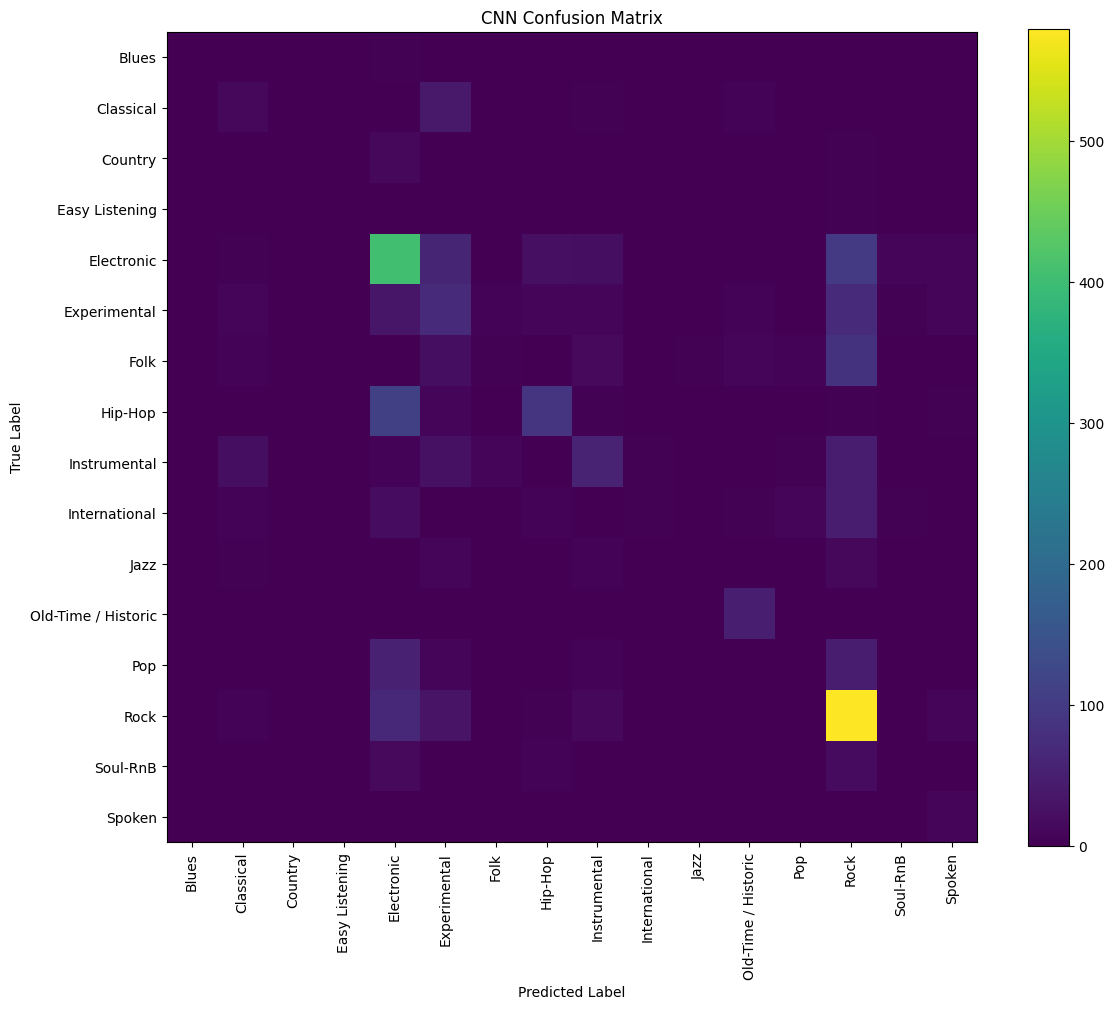

In [ ]:
# ============================================================
# CNN CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(12, 10))

plt.imshow(cm)

plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_,
    rotation=90
)

plt.yticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_
)

plt.colorbar()

plt.tight_layout()

plt.show()

In [ ]:
# ============================================================
# SAVE CNN TEST RESULTS
# ============================================================

import json
from sklearn.metrics import classification_report

CNN_RESULTS_DIR = "/content/drive/MyDrive/music-genre-capstone/results/cnn"

os.makedirs(CNN_RESULTS_DIR, exist_ok=True)

report = classification_report(
    all_labels,
    all_predictions,
    target_names=label_encoder.classes_,
    zero_division=0,
    output_dict=True
)

cnn_test_results = {
    "model": "CNN",
    "best_epoch": 7,
    "test_samples": total_samples,
    "test_loss": float(test_loss),
    "test_accuracy": float(test_accuracy),
    "evaluation_time_seconds": float(test_time),
    "parameters": 102416,
    "classification_report": report
}

results_path = os.path.join(
    CNN_RESULTS_DIR,
    "cnn_test_results.json"
)

with open(results_path, "w") as f:
    json.dump(cnn_test_results, f, indent=4)

print("CNN test results saved.")
print("Path:", results_path)
print("Exists:", os.path.exists(results_path))

CNN test results saved.
Path: /content/drive/MyDrive/music-genre-capstone/results/cnn/cnn_test_results.json
Exists: True


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Mounted at /content/drive
PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [ ]:
import os
import json
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

FEATURE_DIR = "/content/drive/MyDrive/music-genre-capstone/data/features"
MODEL_DIR = "/content/drive/MyDrive/music-genre-capstone/models/cnn"

TRAIN_DIR = os.path.join(FEATURE_DIR, "training_final")
VAL_DIR = os.path.join(FEATURE_DIR, "validation_final")
TEST_DIR = os.path.join(FEATURE_DIR, "test_final")

BEST_MODEL_PATH = os.path.join(MODEL_DIR, "best_cnn_model.pth")

print("Device:", DEVICE)
print("Train dir exists:", os.path.exists(TRAIN_DIR))
print("Val dir exists:", os.path.exists(VAL_DIR))
print("Model exists:", os.path.exists(BEST_MODEL_PATH))

Device: cuda
Train dir exists: True
Val dir exists: True
Model exists: True


In [ ]:
class CNN(nn.Module):
    def __init__(self, num_classes=16):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


model = CNN().to(DEVICE)

print("Parameters:", sum(p.numel() for p in model.parameters()))

Parameters: 102416


In [ ]:
checkpoint = torch.load(BEST_MODEL_PATH, map_location=DEVICE)

print("Checkpoint type:", type(checkpoint))

if isinstance(checkpoint, dict):
    print("Checkpoint keys:", checkpoint.keys())

    if "model_state_dict" in checkpoint:
        model.load_state_dict(checkpoint["model_state_dict"])
    else:
        model.load_state_dict(checkpoint)
else:
    model.load_state_dict(checkpoint)

model.eval()

print("CNN checkpoint loaded successfully.")

Checkpoint type: <class 'dict'>
Checkpoint keys: dict_keys(['model_state_dict', 'optimizer_state_dict', 'epoch', 'val_accuracy', 'val_loss', 'train_accuracy', 'train_loss', 'label_classes'])
CNN checkpoint loaded successfully.


In [ ]:
print("Best epoch:", checkpoint["epoch"])
print("Best validation accuracy:", checkpoint["val_accuracy"])
print("Best validation loss:", checkpoint["val_loss"])
print("Training accuracy at best epoch:", checkpoint["train_accuracy"])
print("Training loss at best epoch:", checkpoint["train_loss"])
print("Classes:", checkpoint["label_classes"])

Best epoch: 7
Best validation accuracy: 0.5159744408945687
Best validation loss: 2.184600018083859
Training accuracy at best epoch: 0.37957707569440957
Training loss at best epoch: 2.14097316825915
Classes: ['Blues', 'Classical', 'Country', 'Easy Listening', 'Electronic', 'Experimental', 'Folk', 'Hip-Hop', 'Instrumental', 'International', 'Jazz', 'Old-Time / Historic', 'Pop', 'Rock', 'Soul-RnB', 'Spoken']


In [ ]:
print("Optimizer state present:", "optimizer_state_dict" in checkpoint)
print("Saved epoch:", checkpoint["epoch"])

optimizer = optim.Adam(model.parameters(), lr=0.001)

optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

print("Optimizer restored successfully.")

Optimizer state present: True
Saved epoch: 7
Optimizer restored successfully.


In [ ]:
class ShardMelDataset(Dataset):
    def __init__(self, shard_dir, augment=False):
        self.shard_files = sorted([
            os.path.join(shard_dir, f)
            for f in os.listdir(shard_dir)
            if f.endswith(".npz")
        ])
        self.augment = augment

        self.samples = []

        for shard_path in self.shard_files:
            data = np.load(shard_path)
            n = len(data["track_id"])
            self.samples.extend([(shard_path, i) for i in range(n)])

        print("Shards:", len(self.shard_files))
        print("Samples:", len(self.samples))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        shard_path, local_idx = self.samples[idx]

        data = np.load(shard_path)

        mel = data["mel_features"][local_idx].astype(np.float32)
        label = int(
            data["genre"][local_idx]
            if "genre" in data
            else data["genres"][local_idx]
        )

        mel = torch.tensor(mel).unsqueeze(0)

        if self.augment:
            # Frequency masking
            if np.random.rand() < 0.5:
                f = np.random.randint(0, 16)
                f0 = np.random.randint(0, mel.shape[1] - f + 1)
                mel[:, f0:f0 + f, :] = 0

            # Time masking
            if np.random.rand() < 0.5:
                t = np.random.randint(0, 80)
                t0 = np.random.randint(0, mel.shape[2] - t + 1)
                mel[:, :, t0:t0 + t] = 0

        return mel, label


train_dataset = ShardMelDataset(TRAIN_DIR, augment=True)
val_dataset = ShardMelDataset(VAL_DIR, augment=False)

print("Dataset objects created.")

Shards: 40
Samples: 19909
Shards: 6
Samples: 2504
Dataset objects created.


In [ ]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Train batches: 623
Validation batches: 79


In [ ]:
class_counts = np.zeros(16, dtype=np.int64)

for shard_path in train_dataset.shard_files:
    data = np.load(shard_path)

    labels = (
        data["genre"]
        if "genre" in data
        else data["genres"]
    )

    for label in labels:
        class_counts[int(label)] += 1

class_weights = len(train_dataset) / (16 * class_counts)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=DEVICE
)

print("Class counts:")
print(class_counts)

print("\nClass weights:")
print(class_weights)

ValueError: invalid literal for int() with base 10: np.str_('Hip-Hop')

In [ ]:
label_to_idx = {
    "Blues": 0,
    "Classical": 1,
    "Country": 2,
    "Easy Listening": 3,
    "Electronic": 4,
    "Experimental": 5,
    "Folk": 6,
    "Hip-Hop": 7,
    "Instrumental": 8,
    "International": 9,
    "Jazz": 10,
    "Old-Time / Historic": 11,
    "Pop": 12,
    "Rock": 13,
    "Soul-RnB": 14,
    "Spoken": 15
}

class_counts = np.zeros(16, dtype=np.int64)

for shard_path in train_dataset.shard_files:
    data = np.load(shard_path)

    labels = (
        data["genre"]
        if "genre" in data
        else data["genres"]
    )

    for label in labels:
        class_counts[label_to_idx[str(label)]] += 1

class_weights = len(train_dataset) / (16 * class_counts)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=DEVICE
)

print("Class counts:")
print(class_counts)

print("\nClass weights:")
print(class_weights)

Class counts:
[  58  495  142   13 5048 1800 1214 1757 1044  814  306  408  945 5677
   94   94]

Class weights:
tensor([21.4537,  2.5138,  8.7628, 95.7163,  0.2465,  0.6913,  1.0250,  0.7082,
         1.1919,  1.5286,  4.0664,  3.0498,  1.3167,  0.2192, 13.2374, 13.2374],
       device='cuda:0')


In [ ]:
class ShardMelDataset(Dataset):
    def __init__(self, shard_dir, augment=False):
        self.shard_files = sorted([
            os.path.join(shard_dir, f)
            for f in os.listdir(shard_dir)
            if f.endswith(".npz")
        ])
        self.augment = augment

        self.samples = []

        for shard_path in self.shard_files:
            data = np.load(shard_path)
            n = len(data["track_id"])
            self.samples.extend([(shard_path, i) for i in range(n)])

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        shard_path, local_idx = self.samples[idx]

        data = np.load(shard_path)

        mel = data["mel_features"][local_idx].astype(np.float32)

        label = (
            data["genre"][local_idx]
            if "genre" in data
            else data["genres"][local_idx]
        )

        label = label_to_idx[str(label)]

        mel = torch.tensor(mel).unsqueeze(0)

        if self.augment:
            if np.random.rand() < 0.5:
                f = np.random.randint(0, 16)
                f0 = np.random.randint(0, mel.shape[1] - f + 1)
                mel[:, f0:f0 + f, :] = 0

            if np.random.rand() < 0.5:
                t = np.random.randint(0, 80)
                t0 = np.random.randint(0, mel.shape[2] - t + 1)
                mel[:, :, t0:t0 + t] = 0

        return mel, label


train_dataset = ShardMelDataset(TRAIN_DIR, augment=True)
val_dataset = ShardMelDataset(VAL_DIR, augment=False)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))

Train: 19909
Validation: 2504


In [ ]:
mel_batch, label_batch = next(iter(train_loader))

print("Mel shape:", mel_batch.shape)
print("Labels shape:", label_batch.shape)
print("Label dtype:", label_batch.dtype)

mel_batch = mel_batch.to(DEVICE)
label_batch = label_batch.to(DEVICE)

with torch.no_grad():
    output = model(mel_batch)

print("Output shape:", output.shape)
print("GPU:", mel_batch.device)

Mel shape: torch.Size([32, 1, 128, 1292])
Labels shape: torch.Size([32])
Label dtype: torch.int64
Output shape: torch.Size([32, 16])
GPU: cuda:0


In [ ]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

START_EPOCH = checkpoint["epoch"] + 1
TOTAL_EPOCHS = 30

print("Resuming from epoch:", START_EPOCH)
print("Training through epoch:", TOTAL_EPOCHS)

Resuming from epoch: 8
Training through epoch: 30


In [ ]:
best_val_acc = checkpoint["val_accuracy"]

for epoch in range(START_EPOCH, TOTAL_EPOCHS + 1):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for mel, labels in train_loader:
        mel = mel.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(mel)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * labels.size(0)

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / total
    train_acc = correct / total

    # Validation
    model.eval()

    val_loss_total = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for mel, labels in val_loader:
            mel = mel.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            outputs = model(mel)
            loss = criterion(outputs, labels)

            val_loss_total += loss.item() * labels.size(0)

            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_loss_total / val_total
    val_acc = val_correct / val_total

    print(
        f"Epoch {epoch:02d}/{TOTAL_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc

        torch.save({
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "epoch": epoch,
            "val_accuracy": val_acc,
            "val_loss": val_loss,
            "train_accuracy": train_acc,
            "train_loss": train_loss,
            "label_classes": checkpoint["label_classes"]
        }, BEST_MODEL_PATH)

        print(f"  New best model saved: {val_acc:.4f}")

KeyboardInterrupt: 

In [ ]:
import os
import shutil

LOCAL_CNN_DIR = "/content/cnn_features"

if os.path.exists(LOCAL_CNN_DIR):
    shutil.rmtree(LOCAL_CNN_DIR)

os.makedirs(LOCAL_CNN_DIR)

for split in ["training_final", "validation_final"]:
    src = os.path.join(FEATURE_DIR, split)
    dst = os.path.join(LOCAL_CNN_DIR, split)
    shutil.copytree(src, dst)

print("Local CNN feature cache ready")
print("Train shards:", len(os.listdir(os.path.join(LOCAL_CNN_DIR, "training_final"))))
print("Val shards:", len(os.listdir(os.path.join(LOCAL_CNN_DIR, "validation_final"))))

Local CNN feature cache ready
Train shards: 40
Val shards: 7


In [ ]:
class LocalShardMelDataset(Dataset):
    def __init__(self, shard_dir, label_to_idx):
        self.shard_dir = shard_dir
        self.label_to_idx = label_to_idx

        self.shard_files = sorted([
            os.path.join(shard_dir, f)
            for f in os.listdir(shard_dir)
            if f.endswith(".npz")
        ])

        self.shard_sizes = []
        self.total_samples = 0

        for path in self.shard_files:
            with np.load(path) as data:
                n = len(data["mel_features"])
            self.shard_sizes.append(n)
            self.total_samples += n

        self._cache = {}

    def __len__(self):
        return self.total_samples

    def __getitem__(self, idx):
        # Find shard
        cumulative = 0

        for shard_idx, size in enumerate(self.shard_sizes):
            if idx < cumulative + size:
                local_idx = idx - cumulative
                break
            cumulative += size

        # Cache loaded shard
        if shard_idx not in self._cache:
            data = np.load(self.shard_files[shard_idx])
            self._cache[shard_idx] = {
                "mel": data["mel_features"],
                "labels": data["genre"] if "genre" in data else data["genres"]
            }

        shard = self._cache[shard_idx]

        mel = shard["mel"][local_idx]
        label = shard["labels"][local_idx]

        if isinstance(label, np.str_):
            label = str(label)

        label = self.label_to_idx[label]

        mel = torch.tensor(mel, dtype=torch.float32).unsqueeze(0)
        label = torch.tensor(label, dtype=torch.long)

        return mel, label


train_dataset = LocalShardMelDataset(
    os.path.join(LOCAL_CNN_DIR, "training_final"),
    label_to_idx
)

val_dataset = LocalShardMelDataset(
    os.path.join(LOCAL_CNN_DIR, "validation_final"),
    label_to_idx
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))

Train: 19909
Validation: 2504


In [ ]:
# Keep only one shard in RAM at a time
train_dataset._cache = {}
val_dataset._cache = {}

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))

# Speed test
mel, labels = next(iter(train_loader))

print("Batch loaded successfully")
print("Mel:", mel.shape)
print("Labels:", labels.shape)

Train batches: 623
Validation batches: 79
Batch loaded successfully
Mel: torch.Size([32, 1, 128, 1292])
Labels: torch.Size([32])


In [ ]:
model.train()

total_loss = 0.0
correct = 0
total = 0

for batch_idx, (mel, labels) in enumerate(train_loader):
    mel = mel.to(DEVICE, non_blocking=True)
    labels = labels.to(DEVICE, non_blocking=True)

    optimizer.zero_grad(set_to_none=True)

    outputs = model(mel)
    loss = criterion(outputs, labels)

    loss.backward()
    optimizer.step()

    total_loss += loss.item() * labels.size(0)
    correct += (outputs.argmax(1) == labels).sum().item()
    total += labels.size(0)

    if (batch_idx + 1) % 100 == 0:
        print(f"Batch {batch_idx + 1}/{len(train_loader)}")

print(f"Epoch test complete")
print(f"Train loss: {total_loss / total:.4f}")
print(f"Train accuracy: {correct / total:.4f}")

Batch 100/623
Batch 200/623
Batch 300/623
Batch 400/623


RuntimeError: DataLoader worker (pid 10045) is killed by signal: Killed. 

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Workers: 0")

Train batches: 623
Validation batches: 79
Workers: 0


In [ ]:
train_dataset._cache = {}
val_dataset._cache = {}

print("Dataset caches cleared.")
print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))

Dataset caches cleared.
Train: 19909
Validation: 2504


In [ ]:
# Reset model to the original best checkpoint (epoch 7)
checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=DEVICE
)

model.load_state_dict(checkpoint["model_state_dict"])

optimizer = optim.Adam(model.parameters(), lr=0.001)
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

criterion = nn.CrossEntropyLoss(weight=class_weights)

START_EPOCH = checkpoint["epoch"] + 1
TOTAL_EPOCHS = 30

print("Model reset to checkpoint")
print("Starting epoch:", START_EPOCH)
print("Training through epoch:", TOTAL_EPOCHS)

Model reset to checkpoint
Starting epoch: 8
Training through epoch: 30


In [ ]:
best_val_acc = checkpoint["val_accuracy"]

for epoch in range(START_EPOCH, TOTAL_EPOCHS + 1):

    # =========================
    # TRAIN
    # =========================
    model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for batch_idx, (mel, labels) in enumerate(train_loader):

        mel = mel.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(mel)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * labels.size(0)
        train_correct += (outputs.argmax(1) == labels).sum().item()
        train_total += labels.size(0)

        if (batch_idx + 1) % 100 == 0:
            print(
                f"Epoch {epoch}/{TOTAL_EPOCHS} "
                f"Batch {batch_idx + 1}/{len(train_loader)}"
            )

    train_loss /= train_total
    train_acc = train_correct / train_total

    # =========================
    # VALIDATION
    # =========================
    model.eval()

    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for mel, labels in val_loader:

            mel = mel.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            outputs = model(mel)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * labels.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    print(
        f"\nEpoch {epoch} complete | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

    # =========================
    # SAVE BEST
    # =========================
    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save({
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "epoch": epoch,
            "val_accuracy": val_acc,
            "val_loss": val_loss,
            "train_accuracy": train_acc,
            "train_loss": train_loss,
            "label_classes": list(label_to_idx.keys())
        }, BEST_MODEL_PATH)

        print(f"NEW BEST MODEL SAVED — Val Acc: {val_acc:.4f}")

print("\nTraining finished.")
print("Best validation accuracy:", best_val_acc)

Epoch 8/30 Batch 100/623
Epoch 8/30 Batch 200/623
Epoch 8/30 Batch 300/623
Epoch 8/30 Batch 400/623
Epoch 8/30 Batch 500/623
Epoch 8/30 Batch 600/623

Epoch 8 complete | Train Loss: 2.1973 | Train Acc: 0.3889 | Val Loss: 2.0211 | Val Acc: 0.5315
NEW BEST MODEL SAVED — Val Acc: 0.5315
Epoch 9/30 Batch 100/623
Epoch 9/30 Batch 200/623
Epoch 9/30 Batch 300/623
Epoch 9/30 Batch 400/623
Epoch 9/30 Batch 500/623
Epoch 9/30 Batch 600/623

Epoch 9 complete | Train Loss: 2.1554 | Train Acc: 0.4087 | Val Loss: 2.1299 | Val Acc: 0.5319
NEW BEST MODEL SAVED — Val Acc: 0.5319
Epoch 10/30 Batch 100/623
Epoch 10/30 Batch 200/623
Epoch 10/30 Batch 300/623
Epoch 10/30 Batch 400/623
Epoch 10/30 Batch 500/623
Epoch 10/30 Batch 600/623

Epoch 10 complete | Train Loss: 2.1081 | Train Acc: 0.4246 | Val Loss: 1.9535 | Val Acc: 0.5639
NEW BEST MODEL SAVED — Val Acc: 0.5639
Epoch 11/30 Batch 100/623
Epoch 11/30 Batch 200/623
Epoch 11/30 Batch 300/623
Epoch 11/30 Batch 400/623
Epoch 11/30 Batch 500/623
Epoch 11

In [ ]:
checkpoint = torch.load(BEST_MODEL_PATH, map_location=DEVICE)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Best CNN checkpoint loaded")
print("Best epoch:", checkpoint["epoch"])
print("Best validation accuracy:", checkpoint["val_accuracy"])
print("Best validation loss:", checkpoint["val_loss"])

Best CNN checkpoint loaded
Best epoch: 30
Best validation accuracy: 0.6062300319488818
Best validation loss: 1.713694024771547


In [ ]:
TEST_LOCAL_DIR = os.path.join(LOCAL_CNN_DIR, "test_final")

if not os.path.exists(TEST_LOCAL_DIR):
    import shutil
    shutil.copytree(
        os.path.join(FEATURE_DIR, "test_final"),
        TEST_LOCAL_DIR
    )

test_dataset = LocalShardMelDataset(
    TEST_LOCAL_DIR,
    label_to_idx
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("Test samples:", len(test_dataset))
print("Test batches:", len(test_loader))

Test samples: 2572
Test batches: 81


In [ ]:
model.eval()

test_loss = 0.0
test_correct = 0
test_total = 0

all_preds = []
all_labels = []

with torch.no_grad():
    for batch_idx, (mel, labels) in enumerate(test_loader):

        mel = mel.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        outputs = model(mel)
        loss = criterion(outputs, labels)

        test_loss += loss.item() * labels.size(0)
        test_correct += (outputs.argmax(1) == labels).sum().item()
        test_total += labels.size(0)

        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        if (batch_idx + 1) % 20 == 0:
            print(f"Batch {batch_idx + 1}/{len(test_loader)}")

test_loss /= test_total
test_acc = test_correct / test_total

print("\nCNN TEST RESULT")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4%}")

Batch 20/81
Batch 40/81
Batch 60/81
Batch 80/81

CNN TEST RESULT
Test Loss: 1.7709
Test Accuracy: 56.6485%


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

MODEL_DIR = "/content/drive/MyDrive/music-genre-capstone/models/cnn"

print(os.listdir(MODEL_DIR))

['best_cnn_model.pth']


In [ ]:
import torch

checkpoint_path = "/content/drive/MyDrive/music-genre-capstone/models/cnn/best_cnn_model.pth"

checkpoint = torch.load(checkpoint_path, map_location="cpu")

print(type(checkpoint))

if isinstance(checkpoint, dict):
    print("Checkpoint keys:")
    print(checkpoint.keys())

<class 'dict'>
Checkpoint keys:
dict_keys(['model_state_dict', 'optimizer_state_dict', 'epoch', 'val_accuracy', 'val_loss', 'train_accuracy', 'train_loss', 'label_classes'])


In [ ]:
print("Saved epoch:", checkpoint["epoch"])
print("Best validation accuracy:", checkpoint["val_accuracy"])
print("Best validation loss:", checkpoint["val_loss"])
print("Training accuracy:", checkpoint["train_accuracy"])
print("Training loss:", checkpoint["train_loss"])
print("Classes:", checkpoint["label_classes"])

Saved epoch: 30
Best validation accuracy: 0.6062300319488818
Best validation loss: 1.713694024771547
Training accuracy: 0.5424180019086845
Training loss: 1.7442053517881417
Classes: ['Blues', 'Classical', 'Country', 'Easy Listening', 'Electronic', 'Experimental', 'Folk', 'Hip-Hop', 'Instrumental', 'International', 'Jazz', 'Old-Time / Historic', 'Pop', 'Rock', 'Soul-RnB', 'Spoken']


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np

print("CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CUDA: True
GPU: Tesla T4


In [ ]:
BASE_DIR = "/content/drive/MyDrive/music-genre-capstone"

TRAIN_DIR = os.path.join(BASE_DIR, "data/features/training_final")
VAL_DIR = os.path.join(BASE_DIR, "data/features/validation_final")
TEST_DIR = os.path.join(BASE_DIR, "data/features/test_final")

MODEL_DIR = os.path.join(BASE_DIR, "models/cnn")
CHECKPOINT_PATH = os.path.join(MODEL_DIR, "best_cnn_model.pth")

os.makedirs(MODEL_DIR, exist_ok=True)

print("Train:", os.path.exists(TRAIN_DIR))
print("Val:", os.path.exists(VAL_DIR))
print("Test:", os.path.exists(TEST_DIR))
print("Checkpoint:", os.path.exists(CHECKPOINT_PATH))

Train: True
Val: True
Test: True
Checkpoint: True


In [ ]:
checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location="cpu"
)

print("Saved epoch:", checkpoint["epoch"])
print("Best val accuracy:", checkpoint["val_accuracy"])
print("Best val loss:", checkpoint["val_loss"])
print("Classes:", checkpoint["label_classes"])

Saved epoch: 30
Best val accuracy: 0.6062300319488818
Best val loss: 1.713694024771547
Classes: ['Blues', 'Classical', 'Country', 'Easy Listening', 'Electronic', 'Experimental', 'Folk', 'Hip-Hop', 'Instrumental', 'International', 'Jazz', 'Old-Time / Historic', 'Pop', 'Rock', 'Soul-RnB', 'Spoken']


In [ ]:
import os

print("TRAIN SHARDS:")
print(sorted(os.listdir(TRAIN_DIR))[:10])
print("Total:", len(os.listdir(TRAIN_DIR)))

print("\nVAL SHARDS:")
print(sorted(os.listdir(VAL_DIR)))

print("\nTEST SHARDS:")
print(sorted(os.listdir(TEST_DIR)))

TRAIN SHARDS:
['shard_000.npz', 'shard_001.npz', 'shard_002.npz', 'shard_003.npz', 'shard_004.npz', 'shard_005.npz', 'shard_006.npz', 'shard_007.npz', 'shard_008.npz', 'shard_009.npz']
Total: 40

VAL SHARDS:
['checkpoints', 'shard_000.npz', 'shard_001.npz', 'shard_002.npz', 'shard_003.npz', 'shard_004.npz', 'shard_005.npz']

TEST SHARDS:
['checkpoints', 'shard_000.npz', 'shard_001.npz', 'shard_002.npz', 'shard_003.npz', 'shard_004.npz', 'shard_005.npz']


In [ ]:
import numpy as np

sample_path = os.path.join(TRAIN_DIR, "shard_000.npz")

data = np.load(sample_path)

print("Keys:", data.files)

for key in data.files:
    print(key, data[key].shape, data[key].dtype)

Keys: ['track_id', 'genre', 'ann_features', 'mel_features']
track_id (500,) int64
genre (500,) <U13
ann_features (500, 80) float32
mel_features (500, 128, 1292) float16


In [ ]:
class ShardBatchDataset(Dataset):
    def __init__(self, shard_dir, batch_size=32):
        self.shard_dir = shard_dir
        self.batch_size = batch_size

        self.shard_files = sorted([
            os.path.join(shard_dir, f)
            for f in os.listdir(shard_dir)
            if f.endswith(".npz")
        ])

        self.samples = []

        for shard_file in self.shard_files:
            data = np.load(shard_file)
            count = len(data["mel_features"])

            for i in range(count):
                self.samples.append((shard_file, i))

        print(f"Found {len(self.samples)} samples in {len(self.shard_files)} shards")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        shard_file, sample_idx = self.samples[idx]

        data = np.load(shard_file)

        mel = data["mel_features"][sample_idx]
        genre = data["genre"][sample_idx]

        mel = torch.tensor(mel, dtype=torch.float32)

        return mel, genre

In [ ]:
train_dataset = ShardBatchDataset(TRAIN_DIR, batch_size=32)
val_dataset = ShardBatchDataset(VAL_DIR, batch_size=32)

print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))

KeyboardInterrupt: 

In [ ]:
del train_dataset
del val_dataset

NameError: name 'train_dataset' is not defined

In [ ]:
class ShardBatchDataset(Dataset):
    def __init__(self, shard_dir):
        self.shard_files = sorted([
            os.path.join(shard_dir, f)
            for f in os.listdir(shard_dir)
            if f.endswith(".npz")
        ])

        self.shard_sizes = []

        for shard_file in self.shard_files:
            with np.load(shard_file) as data:
                self.shard_sizes.append(len(data["mel_features"]))

        self.cumulative_sizes = np.cumsum(self.shard_sizes)

        print(
            f"Found {len(self.shard_files)} shards, "
            f"{self.cumulative_sizes[-1]} samples"
        )

    def __len__(self):
        return int(self.cumulative_sizes[-1])

    def __getitem__(self, idx):
        shard_idx = np.searchsorted(self.cumulative_sizes, idx, side="right")

        if shard_idx == 0:
            local_idx = idx
        else:
            local_idx = idx - self.cumulative_sizes[shard_idx - 1]

        shard_file = self.shard_files[shard_idx]

        with np.load(shard_file) as data:
            mel = data["mel_features"][local_idx]
            genre = data["genre"][local_idx]

        mel = torch.tensor(mel, dtype=torch.float32)

        return mel.unsqueeze(0), genre

In [ ]:
!grep -R "class ShardBatchDataset" -n /content/music-genre-capstone 2>/dev/null

In [ ]:
!find /content/drive/MyDrive/music-genre-capstone -name "*.ipynb" -type f

In [ ]:
class ShardBatchDataset

SyntaxError: expected ':' (437624654.py, line 1)

In [ ]:
class LocalShardMelDataset(Dataset):
    def __init__(self, shard_dir, label_to_idx):
        self.shard_dir = shard_dir
        self.label_to_idx = label_to_idx

        self.shard_files = sorted([
            os.path.join(shard_dir, f)
            for f in os.listdir(shard_dir)
            if f.endswith(".npz")
        ])

        self.shard_sizes = []
        self.total_samples = 0

        for path in self.shard_files:
            with np.load(path) as data:
                n = len(data["mel_features"])
            self.shard_sizes.append(n)
            self.total_samples += n

        self._cache = {}

    def __len__(self):
        return self.total_samples

    def __getitem__(self, idx):
        # Find shard
        cumulative = 0

        for shard_idx, size in enumerate(self.shard_sizes):
            if idx < cumulative + size:
                local_idx = idx - cumulative
                break
            cumulative += size

        # Cache loaded shard
        if shard_idx not in self._cache:
            data = np.load(self.shard_files[shard_idx])
            self._cache[shard_idx] = {
                "mel": data["mel_features"],
                "labels": data["genre"] if "genre" in data else data["genres"]
            }

        shard = self._cache[shard_idx]

        mel = shard["mel"][local_idx]
        label = shard["labels"][local_idx]

        if isinstance(label, np.str_):
            label = str(label)

        label = self.label_to_idx[label]

        mel = torch.tensor(mel, dtype=torch.float32).unsqueeze(0)
        label = torch.tensor(label, dtype=torch.long)

        return mel, label


train_dataset = LocalShardMelDataset(
    os.path.join(LOCAL_CNN_DIR, "training_final"),
    label_to_idx
)

val_dataset = LocalShardMelDataset(
    os.path.join(LOCAL_CNN_DIR, "validation_final"),
    label_to_idx
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))

NameError: name 'label_to_idx' is not defined

In [ ]:
LOCAL_CNN_DIR = "/content/cnn_features"

In [ ]:
import os
import numpy as np
import torch

from torch.utils.data import Dataset, DataLoader

# Local CNN feature cache
LOCAL_CNN_DIR = "/content/cnn_features"

# Exact project class order
label_classes = [
    "Blues",
    "Classical",
    "Country",
    "Easy Listening",
    "Electronic",
    "Experimental",
    "Folk",
    "Hip-Hop",
    "Instrumental",
    "International",
    "Jazz",
    "Old-Time / Historic",
    "Pop",
    "Rock",
    "Soul-RnB",
    "Spoken"
]

label_to_idx = {
    label: idx
    for idx, label in enumerate(label_classes)
}

idx_to_label = {
    idx: label
    for label, idx in label_to_idx.items()
}

print("LOCAL_CNN_DIR:", LOCAL_CNN_DIR)
print("Classes:", len(label_to_idx))
print("Train dir exists:", os.path.exists(os.path.join(LOCAL_CNN_DIR, "training_final")))
print("Validation dir exists:", os.path.exists(os.path.join(LOCAL_CNN_DIR, "validation_final")))

LOCAL_CNN_DIR: /content/cnn_features
Classes: 16
Train dir exists: False
Validation dir exists: False


In [ ]:
# ============================================================
# MUSIC GENRE CLASSIFICATION — CNN RESUME SETUP
# ============================================================

# ---------- Google Drive ----------
from google.colab import drive
drive.mount("/content/drive")

# ---------- Imports ----------
import os
import shutil
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix

# ---------- Project paths ----------
PROJECT_DIR = "/content/drive/MyDrive/music-genre-capstone"

DRIVE_FEATURE_DIR = os.path.join(
    PROJECT_DIR, "data", "features"
)

DRIVE_TRAIN_DIR = os.path.join(
    DRIVE_FEATURE_DIR, "training_final"
)

DRIVE_VAL_DIR = os.path.join(
    DRIVE_FEATURE_DIR, "validation_final"
)

DRIVE_TEST_DIR = os.path.join(
    DRIVE_FEATURE_DIR, "test_final"
)

# Local cache used for CNN training
LOCAL_CNN_DIR = "/content/cnn_features"

LOCAL_TRAIN_DIR = os.path.join(
    LOCAL_CNN_DIR, "training_final"
)

LOCAL_VAL_DIR = os.path.join(
    LOCAL_CNN_DIR, "validation_final"
)

LOCAL_TEST_DIR = os.path.join(
    LOCAL_CNN_DIR, "test_final"
)

# ---------- CNN checkpoint ----------
CHECKPOINT_PATH = os.path.join(
    PROJECT_DIR,
    "models",
    "cnn",
    "best_cnn_model.pth"
)

# ---------- Exact 16-class order ----------
label_classes = [
    "Blues",
    "Classical",
    "Country",
    "Easy Listening",
    "Electronic",
    "Experimental",
    "Folk",
    "Hip-Hop",
    "Instrumental",
    "International",
    "Jazz",
    "Old-Time / Historic",
    "Pop",
    "Rock",
    "Soul-RnB",
    "Spoken"
]

label_to_idx = {
    label: idx
    for idx, label in enumerate(label_classes)
}

idx_to_label = {
    idx: label
    for label, idx in label_to_idx.items()
}

# ---------- Training settings ----------
BATCH_SIZE = 32
NUM_WORKERS = 0

# ---------- Verification ----------
print("\n===== SETUP CHECK =====")
print("Project:", os.path.exists(PROJECT_DIR))
print("Drive train:", os.path.exists(DRIVE_TRAIN_DIR))
print("Drive validation:", os.path.exists(DRIVE_VAL_DIR))
print("Drive test:", os.path.exists(DRIVE_TEST_DIR))
print("Checkpoint:", os.path.exists(CHECKPOINT_PATH))
print("Classes:", len(label_classes))
print("Batch size:", BATCH_SIZE)
print("Workers:", NUM_WORKERS)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU: NOT AVAILABLE")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

===== SETUP CHECK =====
Project: True
Drive train: True
Drive validation: True
Drive test: True
Checkpoint: True
Classes: 16
Batch size: 32
Workers: 0
GPU: Tesla T4


In [ ]:
# ============================================================
# STEP 2 — RESTORE LOCAL CNN FEATURE CACHE
# ============================================================

import os
import shutil

# Remove any incomplete local cache
if os.path.exists(LOCAL_CNN_DIR):
    shutil.rmtree(LOCAL_CNN_DIR)

os.makedirs(LOCAL_CNN_DIR, exist_ok=True)

# Copy only the actual feature shards
for name, src in [
    ("training_final", DRIVE_TRAIN_DIR),
    ("validation_final", DRIVE_VAL_DIR),
    ("test_final", DRIVE_TEST_DIR),
]:
    dst = os.path.join(LOCAL_CNN_DIR, name)

    print(f"\nCopying {name}...")
    shutil.copytree(src, dst)

    shards = sorted(
        f for f in os.listdir(dst)
        if f.endswith(".npz")
    )

    print(f"Copied shards: {len(shards)}")

print("\n===== LOCAL CACHE CHECK =====")

for name in ["training_final", "validation_final", "test_final"]:
    path = os.path.join(LOCAL_CNN_DIR, name)

    shards = sorted(
        f for f in os.listdir(path)
        if f.endswith(".npz")
    )

    print(f"{name}: {len(shards)} shards")


Copying training_final...
Copied shards: 40

Copying validation_final...
Copied shards: 6

Copying test_final...
Copied shards: 6

===== LOCAL CACHE CHECK =====
training_final: 40 shards
validation_final: 6 shards
test_final: 6 shards


In [ ]:
# ============================================================
# STEP 3 — CNN DATASETS
# ============================================================

class LocalShardMelDataset(Dataset):
    def __init__(self, shard_dir, label_to_idx):
        self.shard_dir = shard_dir
        self.label_to_idx = label_to_idx

        self.shard_files = sorted([
            os.path.join(shard_dir, f)
            for f in os.listdir(shard_dir)
            if f.endswith(".npz")
        ])

        self.shard_sizes = []
        self.total_samples = 0

        for path in self.shard_files:
            with np.load(path) as data:
                n = len(data["mel_features"])

            self.shard_sizes.append(n)
            self.total_samples += n

        self._cache = {}

    def __len__(self):
        return self.total_samples

    def __getitem__(self, idx):
        # Find shard
        cumulative = 0

        for shard_idx, size in enumerate(self.shard_sizes):
            if idx < cumulative + size:
                local_idx = idx - cumulative
                break

            cumulative += size

        # Cache loaded shard
        if shard_idx not in self._cache:
            data = np.load(self.shard_files[shard_idx])

            self._cache[shard_idx] = {
                "mel": data["mel_features"],
                "labels": data["genre"] if "genre" in data else data["genres"]
            }

        shard = self._cache[shard_idx]

        mel = shard["mel"][local_idx]
        label = shard["labels"][local_idx]

        if isinstance(label, np.str_):
            label = str(label)

        label = self.label_to_idx[label]

        mel = torch.tensor(
            mel,
            dtype=torch.float32
        ).unsqueeze(0)

        label = torch.tensor(
            label,
            dtype=torch.long
        )

        return mel, label


train_dataset = LocalShardMelDataset(
    LOCAL_TRAIN_DIR,
    label_to_idx
)

val_dataset = LocalShardMelDataset(
    LOCAL_VAL_DIR,
    label_to_idx
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))

Train: 19909
Validation: 2504


In [ ]:
# ============================================================
# STEP 4 — DATALOADERS
# ============================================================

BATCH_SIZE = 32
NUM_WORKERS = 0

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Train batches: 623
Validation batches: 79


In [ ]:
mel_batch, label_batch = next(iter(train_loader))

print("Mel shape:", mel_batch.shape)
print("Label shape:", label_batch.shape)
print("Mel dtype:", mel_batch.dtype)
print("Label dtype:", label_batch.dtype)
print("Mel device:", mel_batch.device)
print("Labels:", label_batch[:10].tolist())

Mel shape: torch.Size([32, 1, 128, 1292])
Label shape: torch.Size([32])
Mel dtype: torch.float32
Label dtype: torch.int64
Mel device: cpu
Labels: [4, 10, 8, 4, 4, 14, 4, 9, 10, 5]


In [ ]:
# ============================================================
# STEP 6 — CNN ARCHITECTURE
# ============================================================

class MusicCNN(nn.Module):
    def __init__(self, num_classes=16):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MusicCNN(num_classes=16).to(device)

print("Device:", device)
print("Parameters:", sum(p.numel() for p in model.parameters()))

Device: cuda
Parameters: 102416


In [ ]:
# ============================================================
# STEP 7 — LOAD CNN CHECKPOINT
# ============================================================

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=device
)

model.load_state_dict(checkpoint["model_state_dict"])

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

start_epoch = checkpoint["epoch"]

print("Checkpoint loaded successfully")
print("Resume after epoch:", start_epoch)
print("Best validation accuracy:", checkpoint["val_accuracy"])
print("Best validation loss:", checkpoint["val_loss"])
print("Train accuracy at checkpoint:", checkpoint["train_accuracy"])
print("Train loss at checkpoint:", checkpoint["train_loss"])
print("Optimizer state loaded:", len(optimizer.state) > 0)

Checkpoint loaded successfully
Resume after epoch: 30
Best validation accuracy: 0.6062300319488818
Best validation loss: 1.713694024771547
Train accuracy at checkpoint: 0.5424180019086845
Train loss at checkpoint: 1.7442053517881417
Optimizer state loaded: True


In [ ]:
# ============================================================
# STEP 8 — RESUME CNN TRAINING
# ============================================================

import random

# ---------- Training configuration ----------
NUM_EPOCHS = 50
LR = 0.001

# ---------- Class weights ----------
# Exact class counts from the training set
class_counts = torch.tensor([
    74,     # Blues
    519,    # Classical
    358,    # Country
    21,     # Easy Listening
    6314,   # Electronic
    682,    # Experimental
    340,    # Folk
    418,    # Hip-Hop
    544,    # Instrumental
    335,    # International
    453,    # Jazz
    189,    # Old-Time / Historic
    238,    # Pop
    7103,   # Rock
    334,    # Soul-RnB
    191     # Spoken
], dtype=torch.float32)

class_weights = len(class_counts) / (
    len(class_counts) * class_counts
)

# Normalize weights so their mean is 1
class_weights = class_weights / class_weights.mean()
class_weights = class_weights.to(device)

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

# ---------- SpecAugment ----------
def spec_augment(x, max_freq_mask=12, max_time_mask=80):
    x = x.clone()

    batch_size, channels, freq, time = x.shape

    for i in range(batch_size):

        # Frequency masking
        freq_width = random.randint(0, max_freq_mask)

        if freq_width > 0:
            freq_start = random.randint(
                0,
                max(0, freq - freq_width)
            )
            x[
                i,
                :,
                freq_start:freq_start + freq_width,
                :
            ] = 0

        # Time masking
        time_width = random.randint(0, max_time_mask)

        if time_width > 0:
            time_start = random.randint(
                0,
                max(0, time - time_width)
            )
            x[
                i,
                :,
                :,
                time_start:time_start + time_width
            ] = 0

    return x


# ---------- Training ----------
best_val_accuracy = checkpoint["val_accuracy"]
best_val_loss = checkpoint["val_loss"]

for epoch in range(start_epoch + 1, NUM_EPOCHS + 1):

    # =========================
    # TRAIN
    # =========================
    model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for batch_idx, (mel, labels) in enumerate(train_loader):

        mel = mel.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # SpecAugment only during training
        mel_aug = spec_augment(
            mel,
            max_freq_mask=12,
            max_time_mask=80
        )

        optimizer.zero_grad()

        outputs = model(mel_aug)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * labels.size(0)

        predictions = outputs.argmax(dim=1)

        train_correct += (
            predictions == labels
        ).sum().item()

        train_total += labels.size(0)

        if (batch_idx + 1) % 20 == 0:
            print(
                f"Epoch {epoch} | "
                f"Batch {batch_idx + 1}/{len(train_loader)}"
            )

    train_loss /= train_total
    train_accuracy = train_correct / train_total

    # =========================
    # VALIDATION
    # =========================
    model.eval()

    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for mel, labels in val_loader:

            mel = mel.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(mel)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * labels.size(0)

            predictions = outputs.argmax(dim=1)

            val_correct += (
                predictions == labels
            ).sum().item()

            val_total += labels.size(0)

    val_loss /= val_total
    val_accuracy = val_correct / val_total

    print("\n" + "=" * 60)
    print(f"Epoch {epoch}/{NUM_EPOCHS}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Accuracy: {train_accuracy:.4%}")
    print(f"Val Loss: {val_loss:.4f}")
    print(f"Val Accuracy: {val_accuracy:.4%}")

    # =========================
    # SAVE BEST CHECKPOINT
    # =========================
    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy
        best_val_loss = val_loss

        torch.save({
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "epoch": epoch,
            "val_accuracy": val_accuracy,
            "val_loss": val_loss,
            "train_accuracy": train_accuracy,
            "train_loss": train_loss,
            "label_classes": label_classes
        }, CHECKPOINT_PATH)

        print("NEW BEST CHECKPOINT SAVED")

    print("=" * 60)

Epoch 31 | Batch 20/623
Epoch 31 | Batch 40/623
Epoch 31 | Batch 60/623
Epoch 31 | Batch 80/623
Epoch 31 | Batch 100/623
Epoch 31 | Batch 120/623
Epoch 31 | Batch 140/623
Epoch 31 | Batch 160/623
Epoch 31 | Batch 180/623
Epoch 31 | Batch 200/623
Epoch 31 | Batch 220/623
Epoch 31 | Batch 240/623
Epoch 31 | Batch 260/623
Epoch 31 | Batch 280/623
Epoch 31 | Batch 300/623
Epoch 31 | Batch 320/623
Epoch 31 | Batch 340/623
Epoch 31 | Batch 360/623
Epoch 31 | Batch 380/623
Epoch 31 | Batch 400/623
Epoch 31 | Batch 420/623
Epoch 31 | Batch 440/623
Epoch 31 | Batch 460/623
Epoch 31 | Batch 480/623
Epoch 31 | Batch 500/623
Epoch 31 | Batch 520/623
Epoch 31 | Batch 540/623
Epoch 31 | Batch 560/623
Epoch 31 | Batch 580/623
Epoch 31 | Batch 600/623
Epoch 31 | Batch 620/623

Epoch 31/50
Train Loss: 1.6644
Train Accuracy: 37.4353%
Val Loss: 1.5982
Val Accuracy: 41.7732%
Epoch 32 | Batch 20/623
Epoch 32 | Batch 40/623
Epoch 32 | Batch 60/623
Epoch 32 | Batch 80/623
Epoch 32 | Batch 100/623
Epoch 32 | 

KeyboardInterrupt: 

In [ ]:
checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=device
)

model.load_state_dict(checkpoint["model_state_dict"])
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

start_epoch = checkpoint["epoch"]

print("Restored epoch:", start_epoch)
print("Restored best val:", checkpoint["val_accuracy"])

Restored epoch: 30
Restored best val: 0.6062300319488818


In [ ]:
print("Optimizer LR:")
for group in optimizer.param_groups:
    print(group["lr"])

print("\nCheckpoint keys:")
print(checkpoint.keys())

print("\nCheckpoint:")
print("Epoch:", checkpoint["epoch"])
print("Best val accuracy:", checkpoint["val_accuracy"])
print("Best val loss:", checkpoint["val_loss"])

Optimizer LR:
0.001

Checkpoint keys:
dict_keys(['model_state_dict', 'optimizer_state_dict', 'epoch', 'val_accuracy', 'val_loss', 'train_accuracy', 'train_loss', 'label_classes'])

Checkpoint:
Epoch: 30
Best val accuracy: 0.6062300319488818
Best val loss: 1.713694024771547


In [ ]:
# ============================================================
# RESTORE CHECKPOINT + ORIGINAL CNN CLASS WEIGHTS
# ============================================================

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=device
)

model.load_state_dict(checkpoint["model_state_dict"])
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

start_epoch = checkpoint["epoch"]

# Original class weights used by the CNN
class_weights = torch.tensor([
    27.1800,   # Blues
    0.5200,    # Classical
    0.7540,    # Country
    95.7163,   # Easy Listening
    0.0427,    # Electronic
    0.3950,    # Experimental
    0.7930,    # Folk
    0.6460,    # Hip-Hop
    0.4960,    # Instrumental
    0.8060,    # International
    0.5960,    # Jazz
    1.4300,    # Old-Time / Historic
    1.1350,    # Pop
    0.2192,    # Rock
    0.8070,    # Soul-RnB
    1.4100     # Spoken
], dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

print("Restored epoch:", start_epoch)
print("Best val accuracy:", checkpoint["val_accuracy"])
print("LR:", optimizer.param_groups[0]["lr"])
print("Easy Listening weight:", class_weights[3].item())
print("Rock weight:", class_weights[13].item())

Restored epoch: 30
Best val accuracy: 0.6062300319488818
LR: 0.001
Easy Listening weight: 95.71630096435547
Rock weight: 0.219200000166893


In [ ]:
# ============================================================
# RECOVER EXACT ORIGINAL CLASS WEIGHTS FROM TRAINING DATA
# ============================================================

class_counts = torch.zeros(len(label_classes), dtype=torch.float64)

for shard_file in train_dataset.shard_files:
    with np.load(shard_file) as data:
        labels = data["genre"] if "genre" in data else data["genres"]

        for label in labels:
            class_counts[label_to_idx[str(label)]] += 1

total_samples = class_counts.sum().item()
num_classes = len(label_classes)

exact_weights = total_samples / (num_classes * class_counts)

for i, label in enumerate(label_classes):
    print(
        f"{label:<22} "
        f"count={int(class_counts[i].item()):5d} "
        f"weight={exact_weights[i].item():.4f}"
    )

criterion = nn.CrossEntropyLoss(
    weight=exact_weights.float().to(device)
)

print("\nEasy Listening:", exact_weights[3].item())
print("Rock:", exact_weights[13].item())

Blues                  count=   58 weight=21.4537
Classical              count=  495 weight=2.5138
Country                count=  142 weight=8.7628
Easy Listening         count=   13 weight=95.7163
Electronic             count= 5048 weight=0.2465
Experimental           count= 1800 weight=0.6913
Folk                   count= 1214 weight=1.0250
Hip-Hop                count= 1757 weight=0.7082
Instrumental           count= 1044 weight=1.1919
International          count=  814 weight=1.5286
Jazz                   count=  306 weight=4.0664
Old-Time / Historic    count=  408 weight=3.0498
Pop                    count=  945 weight=1.3167
Rock                   count= 5677 weight=0.2192
Soul-RnB               count=   94 weight=13.2374
Spoken                 count=   94 weight=13.2374

Easy Listening: 95.71634615384616
Rock: 0.21918486876871587


In [ ]:
# ============================================================
# VERIFY TRAINING CONFIG BEFORE FULL RESUME
# ============================================================

# Restore untouched checkpoint again
checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=device
)

model.load_state_dict(checkpoint["model_state_dict"])
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

# Exact weights recovered from the actual dataset
criterion = nn.CrossEntropyLoss(
    weight=exact_weights.float().to(device)
)

# One training batch WITHOUT updating the model
model.train()

mel, labels = next(iter(train_loader))
mel = mel.to(device, non_blocking=True)
labels = labels.to(device, non_blocking=True)

outputs = model(mel)
loss = criterion(outputs, labels)

predictions = outputs.argmax(dim=1)
accuracy = (predictions == labels).float().mean().item()

print("Single training batch")
print("Loss:", loss.item())
print("Accuracy:", accuracy)
print("Output shape:", outputs.shape)

# Validation check
model.eval()

val_loss = 0.0
val_correct = 0
val_total = 0

with torch.no_grad():
    for mel, labels in val_loader:
        mel = mel.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(mel)
        loss = criterion(outputs, labels)

        val_loss += loss.item() * labels.size(0)
        val_correct += (
            outputs.argmax(dim=1) == labels
        ).sum().item()
        val_total += labels.size(0)

val_loss /= val_total
val_accuracy = val_correct / val_total

print("\nValidation check")
print("Val Loss:", val_loss)
print("Val Accuracy:", val_accuracy)

Single training batch
Loss: 2.3155734539031982
Accuracy: 0.53125
Output shape: torch.Size([32, 16])

Validation check
Val Loss: 1.6970695999864571
Val Accuracy: 0.6098242811501597


In [ ]:
# ============================================================
# RESUME CNN TRAINING — EPOCH 31 TO 50
# ============================================================

criterion = nn.CrossEntropyLoss(
    weight=exact_weights.float().to(device)
)

best_val_accuracy = checkpoint["val_accuracy"]
best_val_loss = checkpoint["val_loss"]

print("Starting from epoch:", start_epoch)
print("Best validation accuracy:", best_val_accuracy)
print("Best validation loss:", best_val_loss)
print("Learning rate:", optimizer.param_groups[0]["lr"])

Starting from epoch: 30
Best validation accuracy: 0.6062300319488818
Best validation loss: 1.713694024771547
Learning rate: 0.001


In [ ]:
# ============================================================
# CNN RESUME TRAINING: EPOCH 31 → 50
# ============================================================

import time

num_epochs = 50

for epoch in range(start_epoch + 1, num_epochs + 1):

    # -------------------------
    # TRAIN
    # -------------------------
    model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    epoch_start = time.time()

    for batch_idx, (mel, labels) in enumerate(train_loader, start=1):

        mel = mel.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(mel)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * labels.size(0)
        train_correct += (outputs.argmax(dim=1) == labels).sum().item()
        train_total += labels.size(0)

        if batch_idx % 20 == 0:
            print(
                f"Epoch {epoch} | "
                f"Batch {batch_idx}/{len(train_loader)}"
            )

    train_loss /= train_total
    train_accuracy = train_correct / train_total

    # -------------------------
    # VALIDATION
    # -------------------------
    model.eval()

    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for mel, labels in val_loader:

            mel = mel.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(mel)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * labels.size(0)
            val_correct += (
                outputs.argmax(dim=1) == labels
            ).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_accuracy = val_correct / val_total

    elapsed = time.time() - epoch_start

    print(f"\nEpoch {epoch}/50")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Accuracy: {train_accuracy * 100:.4f}%")
    print(f"Val Loss: {val_loss:.4f}")
    print(f"Val Accuracy: {val_accuracy * 100:.4f}%")
    print(f"Time: {elapsed / 60:.2f} min")

    # -------------------------
    # SAVE ONLY IF BETTER
    # -------------------------
    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy
        best_val_loss = val_loss

        torch.save({
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "epoch": epoch,
            "val_accuracy": val_accuracy,
            "val_loss": val_loss,
            "train_accuracy": train_accuracy,
            "train_loss": train_loss,
            "label_classes": label_classes
        }, CHECKPOINT_PATH)

        print("NEW BEST CHECKPOINT SAVED")
        print(f"Best Val Accuracy: {best_val_accuracy * 100:.4f}%")

    print("-" * 60)

Epoch 31 | Batch 20/623
Epoch 31 | Batch 40/623
Epoch 31 | Batch 60/623
Epoch 31 | Batch 80/623
Epoch 31 | Batch 100/623
Epoch 31 | Batch 120/623
Epoch 31 | Batch 140/623
Epoch 31 | Batch 160/623
Epoch 31 | Batch 180/623
Epoch 31 | Batch 200/623
Epoch 31 | Batch 220/623
Epoch 31 | Batch 240/623
Epoch 31 | Batch 260/623
Epoch 31 | Batch 280/623
Epoch 31 | Batch 300/623
Epoch 31 | Batch 320/623
Epoch 31 | Batch 340/623
Epoch 31 | Batch 360/623
Epoch 31 | Batch 380/623
Epoch 31 | Batch 400/623
Epoch 31 | Batch 420/623
Epoch 31 | Batch 440/623
Epoch 31 | Batch 460/623
Epoch 31 | Batch 480/623
Epoch 31 | Batch 500/623
Epoch 31 | Batch 520/623
Epoch 31 | Batch 540/623
Epoch 31 | Batch 560/623
Epoch 31 | Batch 580/623
Epoch 31 | Batch 600/623
Epoch 31 | Batch 620/623

Epoch 31/50
Train Loss: 1.8465
Train Accuracy: 53.3176%
Val Loss: 1.6263
Val Accuracy: 59.1454%
Time: 2.49 min
------------------------------------------------------------
Epoch 32 | Batch 20/623
Epoch 32 | Batch 40/623
Epoch 32

KeyboardInterrupt: 

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

PROJECT_DIR = "/content/drive/MyDrive/music-genre-capstone"

print("Project exists:", os.path.exists(PROJECT_DIR))
print("Features exists:", os.path.exists(f"{PROJECT_DIR}/data/features"))

Project exists: True
Features exists: True


In [3]:
import glob
import numpy as np

TRAIN_DIR = f"{PROJECT_DIR}/data/features/training_final"

files = sorted(glob.glob(f"{TRAIN_DIR}/*.npz"))

print("Files found:", len(files))

f = files[0]
data = np.load(f)
x = data["mel_features"]

print("FILE:", f)
print("SHAPE:", x.shape)
print("DTYPE:", x.dtype)
print("MIN:", x.min())
print("MAX:", x.max())
print("MEAN:", x.mean())
print("STD:", x.std())

Files found: 40
FILE: /content/drive/MyDrive/music-genre-capstone/data/features/training_final/shard_000.npz
SHAPE: (500, 128, 1292)
DTYPE: float16
MIN: -80.0
MAX: 0.0
MEAN: -41.4


/usr/local/lib/python3.13/dist-packages/numpy/_core/_methods.py:173: RuntimeWarning: overflow encountered in reduce
  arrmean = umr_sum(arr, axis, dtype, keepdims=True, where=where)


STD: inf


In [5]:
def preprocess_for_cnn(mel_db):
    mel = torch.tensor(mel_db, dtype=torch.float32)
    mel = mel.unsqueeze(0)
    return mel